### Importing Packages

In [1]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

RANDOM_STATE = 42

### Data Loading

In [2]:
df = pd.read_csv(r"D:/PhD EMP/2020/model_df.csv")

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))

Dataset shape: (380193, 95)
Columns: 95


### Dataset Integrity Audit

In [3]:
# ============================================================
# DATASET INTEGRITY AUDIT
# ============================================================

print("Shape:", df.shape)
print("Sessions:", df["session_id"].nunique())
print("Athletes:", df["player_name"].nunique())

# Target
print("Positive athlete-sessions:",
      df.loc[df["injury"] == 1,
             ["player_name", "session_id"]]
      .drop_duplicates()
      .shape[0])

print("Positive athletes:",
      df.loc[df["injury"] == 1, "player_name"].nunique())

# Duplicate athlete-session-minute observations
dup_key = ["player_name", "session_id", "minute_idx"]

n_duplicates = df.duplicated(
    subset=dup_key,
    keep=False
).sum()

print("Duplicate athlete-session-minute rows:", n_duplicates)

# Basic assertions
assert df["player_name"].notna().all()
assert df["session_id"].notna().all()
assert df["minute_idx"].notna().all()
assert df["injury"].isin([0, 1]).all()
assert n_duplicates == 0

print("✓ Basic dataset integrity checks passed")

Shape: (380193, 95)
Sessions: 251
Athletes: 48
Positive athlete-sessions: 22
Positive athletes: 5
Duplicate athlete-session-minute rows: 0
✓ Basic dataset integrity checks passed


In [4]:
# ============================================================
# DATASET INTEGRITY AUDIT
# ============================================================

print("Shape:", df.shape)
print("Sessions:", df["session_id"].nunique())
print("Athletes:", df["player_name"].nunique())

# Target
print("Positive athlete-sessions:",
      df.loc[df["injury"] == 1,
             ["player_name", "session_id"]]
      .drop_duplicates()
      .shape[0])

print("Positive athletes:",
      df.loc[df["injury"] == 1, "player_name"].nunique())

# Duplicate athlete-session-minute observations
dup_key = ["player_name", "session_id", "minute_idx"]

n_duplicates = df.duplicated(
    subset=dup_key,
    keep=False
).sum()

print("Duplicate athlete-session-minute rows:", n_duplicates)

# Basic assertions
assert df["player_name"].notna().all()
assert df["session_id"].notna().all()
assert df["minute_idx"].notna().all()
assert df["injury"].isin([0, 1]).all()
assert n_duplicates == 0

print("✓ Basic dataset integrity checks passed")

Shape: (380193, 95)
Sessions: 251
Athletes: 48
Positive athlete-sessions: 22
Positive athletes: 5
Duplicate athlete-session-minute rows: 0
✓ Basic dataset integrity checks passed


### Session-Level Outcome Table

In [5]:
# ============================================================
# SESSION-LEVEL OUTCOME TABLE
# One row per athlete-session
# ============================================================

session_table = (
    df[
        ["player_name", "session_id", "injury"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Recover team and date from session_id / player_name
session_table["team"] = (
    session_table["player_name"]
    .astype(str)
    .str.split("-", n=1)
    .str[0]
)

session_table["date"] = pd.to_datetime(
    session_table["session_id"]
    .str.rsplit("_", n=1)
    .str[-1],
    errors="coerce"
)

# Checks
assert not session_table.duplicated(
    ["player_name", "session_id"]
).any()

assert session_table["date"].notna().all()

print("Athlete-sessions:", len(session_table))
print("Athletes:", session_table["player_name"].nunique())
print("Teams:", session_table["team"].value_counts().to_dict())

print("\nPositive athlete-sessions:",
      int(session_table["injury"].sum()))

print("Positive athletes:",
      session_table.loc[
          session_table["injury"] == 1,
          "player_name"
      ].nunique())

print("✓ One row per athlete-session")

Athlete-sessions: 3743
Athletes: 48
Teams: {'TeamA': 2259, 'TeamB': 1484}

Positive athlete-sessions: 22
Positive athletes: 5
✓ One row per athlete-session


In [6]:
### Positive Outcome Temporal Audit

In [7]:
# ============================================================
# POSITIVE OUTCOME TEMPORAL AUDIT
# ============================================================

positive_sessions = (
    session_table.loc[
        session_table["injury"] == 1,
        ["player_name", "session_id", "date"]
    ]
    .sort_values(["player_name", "date"])
    .copy()
)

positive_sessions["days_since_previous_positive"] = (
    positive_sessions
    .groupby("player_name")["date"]
    .diff()
    .dt.days
)

print("Positive sessions:", len(positive_sessions))
print("Positive athletes:", positive_sessions["player_name"].nunique())

print("\nPositive sessions per athlete:")
print(
    positive_sessions["player_name"]
    .value_counts()
)

print("\nPositive sessions by month:")
print(
    positive_sessions["date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

print("\nGap distribution between positive sessions:")
print(
    positive_sessions["days_since_previous_positive"]
    .value_counts(dropna=False)
    .sort_index()
)

Positive sessions: 22
Positive athletes: 5

Positive sessions per athlete:
TeamA-4051bba7-1170-4c43-b912-8c38815a7625    10
TeamA-5cd7a61b-88b2-46d2-94f8-5a0d4f682d93     5
TeamA-3e5f6e2b-46b7-4890-84a9-3bbb2649af5a     4
TeamA-5a5b135d-d146-4b4c-b3da-efcd4d203f95     2
TeamA-82a0cc6a-a398-4c89-b5fb-34bc4b53dbea     1
Name: player_name, dtype: int64

Positive sessions by month:
2020-06    15
2020-07     2
2020-08     3
2020-09     2
Freq: M, Name: date, dtype: int64

Gap distribution between positive sessions:
1.0     4
2.0     1
3.0     2
4.0     1
5.0     2
6.0     1
7.0     1
17.0    1
21.0    1
26.0    1
28.0    1
42.0    1
NaN     5
Name: days_since_previous_positive, dtype: int64


### Team-Level Outcome Audit

In [8]:
# ============================================================
# TEAM-LEVEL OUTCOME AUDIT
# ============================================================

team_audit = (
    session_table
    .groupby("team")
    .agg(
        athlete_sessions=("session_id", "size"),
        athletes=("player_name", "nunique"),
        positive_sessions=("injury", "sum")
    )
)

team_audit["prevalence"] = (
    team_audit["positive_sessions"]
    / team_audit["athlete_sessions"]
)

display(team_audit)

print("\nPositive athletes by team:")
print(
    session_table.loc[
        session_table["injury"] == 1
    ]
    .groupby("team")["player_name"]
    .nunique()
)

,athlete_sessions,athletes,positive_sessions,prevalence
team,,,,
TeamA,2259,27,22,0.009739
TeamB,1484,21,0,0.000000



Positive athletes by team:
team
TeamA    5
Name: player_name, dtype: int64


In [9]:
### Primary Cohort: TeamA

In [10]:
# ============================================================
# PRIMARY COHORT: TEAMA ONLY
# ============================================================

teamA_table = (
    session_table.loc[
        session_table["team"] == "TeamA"
    ]
    .copy()
    .sort_values(
        ["player_name", "date", "session_id"]
    )
    .reset_index(drop=True)
)

print("TeamA athlete-sessions:", len(teamA_table))
print("TeamA athletes:", teamA_table["player_name"].nunique())
print("TeamA positives:", int(teamA_table["injury"].sum()))

print(
    "TeamA positive athletes:",
    teamA_table.loc[
        teamA_table["injury"] == 1,
        "player_name"
    ].nunique()
)

print(
    "TeamA prevalence:",
    teamA_table["injury"].mean()
)

TeamA athlete-sessions: 2259
TeamA athletes: 27
TeamA positives: 22
TeamA positive athletes: 5
TeamA prevalence: 0.009738822487826471


In [11]:
### Athlete-Level Outcome Structure

In [12]:
# ============================================================
# ATHLETE-LEVEL OUTCOME STRUCTURE — TEAMA
# ============================================================

athlete_outcome = (
    teamA_table
    .groupby("player_name")
    .agg(
        n_sessions=("session_id", "size"),
        n_positive=("injury", "sum"),
        first_date=("date", "min"),
        last_date=("date", "max")
    )
    .reset_index()
)

athlete_outcome["ever_positive"] = (
    athlete_outcome["n_positive"] > 0
).astype(int)

positive_athletes = (
    athlete_outcome.loc[
        athlete_outcome["n_positive"] > 0
    ]
    .sort_values("n_positive", ascending=False)
    .copy()
)

positive_athletes["fraction_of_all_positives"] = (
    positive_athletes["n_positive"]
    / positive_athletes["n_positive"].sum()
)

display(positive_athletes)

print(
    "\nNegative-athlete session distribution:"
)

print(
    athlete_outcome.loc[
        athlete_outcome["n_positive"] == 0,
        "n_sessions"
    ].describe()
)

,player_name,n_sessions,n_positive,first_date,last_date,ever_positive,fraction_of_all_positives
7,TeamA-4051bba7-1170-4c43-b912-8c38815a7625,94,10,2020-06-01,2020-12-06,1,0.454545
12,TeamA-5cd7a61b-88b2-46d2-94f8-5a0d4f682d93,119,5,2020-06-01,2020-12-06,1,0.227273
6,TeamA-3e5f6e2b-46b7-4890-84a9-3bbb2649af5a,10,4,2020-06-01,2020-06-12,1,0.181818
11,TeamA-5a5b135d-d146-4b4c-b3da-efcd4d203f95,101,2,2020-06-09,2020-12-06,1,0.090909
16,TeamA-82a0cc6a-a398-4c89-b5fb-34bc4b53dbea,71,1,2020-07-13,2020-12-06,1,0.045455



Negative-athlete session distribution:
count     22.000000
mean      84.727273
std       35.841160
min        3.000000
25%       66.250000
50%       92.500000
75%      114.750000
max      123.000000
Name: n_sessions, dtype: float64


In [13]:
### Temporal Outcome Distribution

In [14]:
# ============================================================
# TEMPORAL OUTCOME DISTRIBUTION — TEAMA
# ============================================================

temporal_audit = teamA_table.copy()

temporal_audit["month"] = (
    temporal_audit["date"].dt.to_period("M")
)

monthly_outcomes = (
    temporal_audit
    .groupby("month")
    .agg(
        sessions=("session_id", "size"),
        positives=("injury", "sum"),
        athletes=("player_name", "nunique")
    )
)

monthly_outcomes["prevalence"] = (
    monthly_outcomes["positives"]
    / monthly_outcomes["sessions"]
)

display(monthly_outcomes)

print("\nPositive vs negative date distribution:")

print(
    temporal_audit
    .groupby("injury")["date"]
    .agg(["min", "max", "count"])
)

,sessions,positives,athletes,prevalence
month,,,,
2020-06,435,15,24,0.034483
2020-07,390,2,23,0.005128
2020-08,422,3,22,0.007109
2020-09,319,2,24,0.006270
2020-10,393,0,22,0.000000
2020-11,254,0,22,0.000000
2020-12,46,0,19,0.000000



Positive vs negative date distribution:
              min        max  count
injury                             
0      2020-06-01 2020-12-06   2237
1      2020-06-03 2020-09-25     22


In [15]:
### Athlete-Disjoint Outer Validation Folds

In [16]:
# ============================================================
# ATHLETE-DISJOINT OUTER VALIDATION FOLDS
# ============================================================

positive_athlete_names = (
    athlete_outcome.loc[
        athlete_outcome["n_positive"] > 0,
        "player_name"
    ]
    .tolist()
)

negative_athlete_names = (
    athlete_outcome.loc[
        athlete_outcome["n_positive"] == 0,
        "player_name"
    ]
    .tolist()
)

# Deterministic ordering for reproducibility
positive_athlete_names = sorted(positive_athlete_names)
negative_athlete_names = sorted(negative_athlete_names)

N_FOLDS = len(positive_athlete_names)

assert N_FOLDS == 5

# Distribute negative athletes across the five folds
negative_chunks = np.array_split(
    negative_athlete_names,
    N_FOLDS
)

outer_folds = []

for fold_idx in range(N_FOLDS):

    test_athletes = (
        [positive_athlete_names[fold_idx]]
        + list(negative_chunks[fold_idx])
    )

    train_athletes = [
        p for p in athlete_outcome["player_name"]
        if p not in test_athletes
    ]

    train_df = teamA_table[
        teamA_table["player_name"].isin(train_athletes)
    ]

    test_df = teamA_table[
        teamA_table["player_name"].isin(test_athletes)
    ]

    outer_folds.append({
        "fold": fold_idx + 1,
        "train_athletes": train_athletes,
        "test_athletes": test_athletes
    })

    print("=" * 60)
    print("Fold:", fold_idx + 1)
    print("Train athletes:", len(train_athletes))
    print("Test athletes:", len(test_athletes))
    print("Train sessions:", len(train_df))
    print("Test sessions:", len(test_df))
    print("Train positives:", int(train_df["injury"].sum()))
    print("Test positives:", int(test_df["injury"].sum()))
    print(
        "Test positive athletes:",
        test_df.loc[
            test_df["injury"] == 1,
            "player_name"
        ].nunique()
    )

    assert set(train_athletes).isdisjoint(
        set(test_athletes)
    )

# Every TeamA athlete must appear in exactly one test fold
all_test_athletes = [
    athlete
    for fold in outer_folds
    for athlete in fold["test_athletes"]
]

assert len(all_test_athletes) == len(set(all_test_athletes))
assert set(all_test_athletes) == set(
    athlete_outcome["player_name"]
)

print("\n✓ Every TeamA athlete appears in exactly one outer test fold")
print("✓ Train/test athletes are disjoint in every fold")

Fold: 1
Train athletes: 21
Test athletes: 6
Train sessions: 1830
Test sessions: 429
Train positives: 18
Test positives: 4
Test positive athletes: 1
Fold: 2
Train athletes: 21
Test athletes: 6
Train sessions: 1770
Test sessions: 489
Train positives: 12
Test positives: 10
Test positive athletes: 1
Fold: 3
Train athletes: 22
Test athletes: 5
Train sessions: 1879
Test sessions: 380
Train positives: 20
Test positives: 2
Test positive athletes: 1
Fold: 4
Train athletes: 22
Test athletes: 5
Train sessions: 1727
Test sessions: 532
Train positives: 17
Test positives: 5
Test positive athletes: 1
Fold: 5
Train athletes: 22
Test athletes: 5
Train sessions: 1830
Test sessions: 429
Train positives: 21
Test positives: 1
Test positive athletes: 1

✓ Every TeamA athlete appears in exactly one outer test fold
✓ Train/test athletes are disjoint in every fold


In [17]:
### Feature Families

In [18]:
# ============================================================
# FEATURE FAMILIES
# ============================================================

# Pre-session context
pre_session_features = [
    "ctl28",
    "ctl42",
    "daily_load",
    "weekly_load",
    "acwr",
    "monotony",
    "strain",
    "sleep_duration",
    "sleep_quality",
    "fatigue",
    "mood",
    "readiness",
    "soreness",
    "stress"
]

# Cumulative information available up to minute X
cumulative_features = [
    c for c in df.columns
    if "_cum_" in c
]

# Dynamic within-session information available up to minute X
dynamic_features = [
    c for c in df.columns
    if (
        c.endswith("_delta")
        or "_roll_mean" in c
        or "_roll_std" in c
        or c.endswith("_spike")
    )
]

# Primary analysis:
# sensor-derived features only
primary_features = list(dict.fromkeys(
    cumulative_features + dynamic_features
))

print("Pre-session features:", len(pre_session_features))
print("Cumulative features:", len(cumulative_features))
print("Dynamic features:", len(dynamic_features))
print("Primary features:", len(primary_features))

assert len(pre_session_features) == 14
assert len(cumulative_features) == 30
assert len(dynamic_features) == 33
assert len(primary_features) == 63

print("✓ Feature families defined")

Pre-session features: 14
Cumulative features: 30
Dynamic features: 33
Primary features: 63
✓ Feature families defined


In [19]:
### Feature Leakage Audit

In [20]:
# ============================================================
# FEATURE LEAKAGE AUDIT
# ============================================================

forbidden_exact = {
    "injury",
    "illness",
    "player_name",
    "session_id",
    "team",
    "date",
    "minute",
    "minute_idx"
}

forbidden_found = [
    c for c in primary_features
    if c in forbidden_exact
]

missing_features = [
    c for c in primary_features
    if c not in df.columns
]

duplicate_features = (
    len(primary_features)
    - len(set(primary_features))
)

print("Primary features:", len(primary_features))
print("Forbidden features found:", forbidden_found)
print("Missing features:", missing_features)
print("Duplicate features:", duplicate_features)

assert len(forbidden_found) == 0
assert len(missing_features) == 0
assert duplicate_features == 0

print("✓ No identifiers, target, date, or explicit elapsed-time variables in primary predictors")

Primary features: 63
Forbidden features found: []
Missing features: []
Duplicate features: 0
✓ No identifiers, target, date, or explicit elapsed-time variables in primary predictors


In [21]:
### Feature Missingness Audit|

In [22]:
# ============================================================
# FEATURE MISSINGNESS AUDIT
# ============================================================

feature_families = {
    "PRE_SESSION": pre_session_features,
    "CUMULATIVE": cumulative_features,
    "DYNAMIC": dynamic_features
}

for family_name, features in feature_families.items():

    missing_fraction = (
        df[features]
        .isna()
        .mean()
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 60)
    print(family_name)
    print("N features:", len(features))
    print(
        "Features with any missingness:",
        int((missing_fraction > 0).sum())
    )
    print(
        "Maximum missing fraction:",
        missing_fraction.max()
    )

    print("\nTop missing:")
    print(
        missing_fraction[
            missing_fraction > 0
        ].head(10)
    )


PRE_SESSION
N features: 14
Features with any missingness: 14
Maximum missing fraction: 0.4972974252550678

Top missing:
sleep_duration    0.497297
sleep_quality     0.497297
readiness         0.492744
fatigue           0.492729
stress            0.492694
mood              0.492542
soreness          0.492542
ctl28             0.280108
ctl42             0.280108
daily_load        0.280108
dtype: float64

CUMULATIVE
N features: 30
Features with any missingness: 10
Maximum missing fraction: 0.00984499977642934

Top missing:
gyro_z_std_cum_std               0.009845
hacc_mean_cum_std                0.009845
accl_z_std_cum_std               0.009845
accl_x_std_cum_std               0.009845
inst_acc_impulse_mean_cum_std    0.009845
gyro_x_std_cum_std               0.009845
accl_y_std_cum_std               0.009845
gyro_y_std_cum_std               0.009845
heart_rate_mean_cum_std          0.009845
speed_mean_cum_std               0.009845
dtype: float64

DYNAMIC
N features: 33
Features with 

In [23]:
### Feature Missingness Audit

In [24]:
# ============================================================
# FEATURE MISSINGNESS AUDIT
# ============================================================

feature_families = {
    "PRE_SESSION": pre_session_features,
    "CUMULATIVE": cumulative_features,
    "DYNAMIC": dynamic_features
}

for family_name, features in feature_families.items():

    missing_fraction = (
        df[features]
        .isna()
        .mean()
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 60)
    print(family_name)
    print("N features:", len(features))
    print(
        "Features with any missingness:",
        int((missing_fraction > 0).sum())
    )
    print(
        "Maximum missing fraction:",
        missing_fraction.max()
    )

    print("\nTop missing:")
    print(
        missing_fraction[
            missing_fraction > 0
        ].head(10)
    )


PRE_SESSION
N features: 14
Features with any missingness: 14
Maximum missing fraction: 0.4972974252550678

Top missing:
sleep_duration    0.497297
sleep_quality     0.497297
readiness         0.492744
fatigue           0.492729
stress            0.492694
mood              0.492542
soreness          0.492542
ctl28             0.280108
ctl42             0.280108
daily_load        0.280108
dtype: float64

CUMULATIVE
N features: 30
Features with any missingness: 10
Maximum missing fraction: 0.00984499977642934

Top missing:
gyro_z_std_cum_std               0.009845
hacc_mean_cum_std                0.009845
accl_z_std_cum_std               0.009845
accl_x_std_cum_std               0.009845
inst_acc_impulse_mean_cum_std    0.009845
gyro_x_std_cum_std               0.009845
accl_y_std_cum_std               0.009845
gyro_y_std_cum_std               0.009845
heart_rate_mean_cum_std          0.009845
speed_mean_cum_std               0.009845
dtype: float64

DYNAMIC
N features: 33
Features with 

In [25]:
### Missingness by Outcome

In [26]:
# ============================================================
# PRE-SESSION MISSINGNESS BY OUTCOME
# One observation per athlete-session
# ============================================================

session_missingness = (
    df[
        ["player_name", "session_id", "injury"]
        + pre_session_features
    ]
    .drop_duplicates(
        subset=["player_name", "session_id"]
    )
    .copy()
)

session_missingness["missing_fraction"] = (
    session_missingness[pre_session_features]
    .isna()
    .mean(axis=1)
)

print(
    "Session-level observations:",
    len(session_missingness)
)

print("\nMissingness by injury status:")

print(
    session_missingness
    .groupby("injury")["missing_fraction"]
    .agg(["count", "mean", "median", "std"])
)

# Feature-specific availability
availability_by_outcome = []

for feature in pre_session_features:

    neg_available = (
        session_missingness.loc[
            session_missingness["injury"] == 0,
            feature
        ]
        .notna()
        .mean()
    )

    pos_available = (
        session_missingness.loc[
            session_missingness["injury"] == 1,
            feature
        ]
        .notna()
        .mean()
    )

    availability_by_outcome.append({
        "feature": feature,
        "available_negative": neg_available,
        "available_positive": pos_available,
        "difference_pos_minus_neg":
            pos_available - neg_available
    })

availability_by_outcome = pd.DataFrame(
    availability_by_outcome
).sort_values("difference_pos_minus_neg")

display(availability_by_outcome)

Session-level observations: 3743

Missingness by injury status:
        count      mean    median       std
injury                                     
0        3721  0.400046  0.357143  0.424841
1          22  0.188312  0.000000  0.232811


,feature,available_negative,available_positive,difference_pos_minus_neg
7,sleep_duration,0.495297,0.590909,0.095612
8,sleep_quality,0.495297,0.590909,0.095612
10,mood,0.496909,0.636364,0.139454
12,soreness,0.496909,0.636364,0.139454
9,fatigue,0.496641,0.636364,0.139723
11,readiness,0.496641,0.636364,0.139723
13,stress,0.496641,0.636364,0.139723
0,ctl28,0.703574,1.000000,0.296426
1,ctl42,0.703574,1.000000,0.296426
2,daily_load,0.703574,1.000000,0.296426


### Primary Feature Set

In [27]:
# ============================================================
# PRIMARY FEATURE SET
# Sensor-derived features only
# ============================================================

primary_features = list(dict.fromkeys(
    cumulative_features + dynamic_features
))

print("Primary features:", len(primary_features))

# Safety checks
forbidden = {
    "injury",
    "illness",
    "player_name",
    "session_id",
    "team",
    "date",
    "minute",
    "minute_idx"
}

assert len(primary_features) == 63
assert not any(c in forbidden for c in primary_features)

print("✓ Primary analysis excludes pre-session variables")
print("✓ Primary analysis uses sensor-derived temporal features only")

Primary features: 63
✓ Primary analysis excludes pre-session variables
✓ Primary analysis uses sensor-derived temporal features only


In [28]:
### Landmark Dataset Construction

In [29]:
# ============================================================
# LANDMARK DATASET CONSTRUCTION — TEAMA
# ============================================================

LANDMARKS = [10, 20, 30, 40, 50, 60]

# TeamA minute-level data only
teamA_minutes = (
    df.loc[
        df["player_name"].isin(teamA_table["player_name"])
    ]
    .copy()
)

landmark_datasets = {}

for x in LANDMARKS:

    # Exact observation at minute X
    dx = (
        teamA_minutes.loc[
            teamA_minutes["minute_idx"] == x,
            ["player_name", "session_id", "injury"]
            + primary_features
        ]
        .copy()
    )

    # Safety: exactly one row per athlete-session
    assert not dx.duplicated(
        ["player_name", "session_id"]
    ).any()

    landmark_datasets[x] = dx.reset_index(drop=True)

    print(
        f"{x:>2} min | "
        f"sessions={len(dx):>4} | "
        f"athletes={dx['player_name'].nunique():>2} | "
        f"positives={int(dx['injury'].sum()):>2} | "
        f"positive athletes="
        f"{dx.loc[dx['injury'] == 1, 'player_name'].nunique()}"
    )

10 min | sessions=2258 | athletes=27 | positives=22 | positive athletes=5
20 min | sessions=2258 | athletes=27 | positives=22 | positive athletes=5
30 min | sessions=2257 | athletes=27 | positives=22 | positive athletes=5
40 min | sessions=2250 | athletes=27 | positives=22 | positive athletes=5
50 min | sessions=2218 | athletes=27 | positives=22 | positive athletes=5
60 min | sessions=2104 | athletes=27 | positives=22 | positive athletes=5


In [30]:
### Landmark Validation Audit

In [31]:
# ============================================================
# VERIFY OUTER FOLDS AT EVERY LANDMARK
# ============================================================

for x, dx in landmark_datasets.items():

    all_test_keys = []

    print("\n" + "=" * 60)
    print(f"LANDMARK {x} MIN")

    for fold in outer_folds:

        train = dx.loc[
            dx["player_name"].isin(fold["train_athletes"])
        ]

        test = dx.loc[
            dx["player_name"].isin(fold["test_athletes"])
        ]

        # No athlete leakage
        assert set(train["player_name"]).isdisjoint(
            set(test["player_name"])
        )

        # Store athlete-session keys tested in this fold
        all_test_keys.extend(
            list(zip(
                test["player_name"],
                test["session_id"]
            ))
        )

        print(
            f"Fold {fold['fold']}: "
            f"train={len(train)} "
            f"(pos={int(train['injury'].sum())}) | "
            f"test={len(test)} "
            f"(pos={int(test['injury'].sum())})"
        )

    # Every available athlete-session must enter
    # exactly one outer test fold
    assert len(all_test_keys) == len(dx)
    assert len(all_test_keys) == len(set(all_test_keys))

    print(
        f"✓ {len(dx)} athlete-sessions covered "
        "exactly once in outer testing"
    )


LANDMARK 10 MIN
Fold 1: train=1829 (pos=18) | test=429 (pos=4)
Fold 2: train=1769 (pos=12) | test=489 (pos=10)
Fold 3: train=1879 (pos=20) | test=379 (pos=2)
Fold 4: train=1726 (pos=17) | test=532 (pos=5)
Fold 5: train=1829 (pos=21) | test=429 (pos=1)
✓ 2258 athlete-sessions covered exactly once in outer testing

LANDMARK 20 MIN
Fold 1: train=1829 (pos=18) | test=429 (pos=4)
Fold 2: train=1769 (pos=12) | test=489 (pos=10)
Fold 3: train=1879 (pos=20) | test=379 (pos=2)
Fold 4: train=1726 (pos=17) | test=532 (pos=5)
Fold 5: train=1829 (pos=21) | test=429 (pos=1)
✓ 2258 athlete-sessions covered exactly once in outer testing

LANDMARK 30 MIN
Fold 1: train=1828 (pos=18) | test=429 (pos=4)
Fold 2: train=1768 (pos=12) | test=489 (pos=10)
Fold 3: train=1879 (pos=20) | test=378 (pos=2)
Fold 4: train=1725 (pos=17) | test=532 (pos=5)
Fold 5: train=1828 (pos=21) | test=429 (pos=1)
✓ 2257 athlete-sessions covered exactly once in outer testing

LANDMARK 40 MIN
Fold 1: train=1823 (pos=18) | test=427

### Methodological Checkpoint

The primary analysis is restricted to TeamA because all recorded positive
athlete-sessions occurred in that team, while TeamB contained no positive
sessions. This restriction reduces the risk that model performance is driven
by team identity rather than injury-status-associated signal.

Evaluation uses five athlete-disjoint outer folds. Each of the five athletes
with at least one positive session is held out in exactly one fold together
with a subset of negative athletes. Consequently, no athlete appears in both
training and test data within the same fold.

The primary predictors are 63 sensor-derived cumulative and dynamic features.
Pre-session workload, sleep, and wellness variables are excluded from the
primary model because their availability differs substantially between positive
and negative sessions.

Models are evaluated at predefined landmarks of 10, 20, 30, 40, 50, and
60 minutes. At each landmark, exactly one observation per athlete-session is
used, avoiding pseudo-replication from multiple minute-level rows of the same
session.

The binary outcome represents recorded same-day injury status. Because the
dataset does not provide verified within-session injury-onset timestamps, the
analysis is interpreted as cross-athlete discrimination of injury-status-
associated sessions rather than prediction of future injury onset.

### Modelling Setup

In [32]:
# ============================================================
# MODELLING IMPORTS
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)

print("✓ Modelling packages imported")

✓ Modelling packages imported


In [33]:
### Baseline Regularized Logistic Regression

In [34]:
# ============================================================
# BASELINE MODEL
# Regularized logistic regression
# ============================================================

baseline_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])

print(baseline_model)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42, solver='liblinear'))])


In [35]:
### Athlete-Disjoint Out-of-Fold Evaluation

In [36]:
# ============================================================
# ATHLETE-DISJOINT OUT-OF-FOLD EVALUATION
# ============================================================

def evaluate_landmark_model(
    dx,
    features,
    outer_folds,
    model
):

    oof_rows = []

    for fold in outer_folds:

        train = dx.loc[
            dx["player_name"].isin(
                fold["train_athletes"]
            )
        ].copy()

        test = dx.loc[
            dx["player_name"].isin(
                fold["test_athletes"]
            )
        ].copy()

        X_train = train[features]
        y_train = train["injury"].astype(int)

        X_test = test[features]
        y_test = test["injury"].astype(int)

        # Safety checks
        assert set(train["player_name"]).isdisjoint(
            set(test["player_name"])
        )

        assert y_train.nunique() == 2
        assert y_test.nunique() == 2

        # Fit ONLY on outer-training data
        model.fit(X_train, y_train)

        # Continuous model scores / probabilities
        y_prob = model.predict_proba(X_test)[:, 1]

        fold_predictions = pd.DataFrame({
            "player_name": test["player_name"].values,
            "session_id": test["session_id"].values,
            "injury": y_test.values,
            "y_prob": y_prob,
            "fold": fold["fold"]
        })

        oof_rows.append(fold_predictions)

    oof = pd.concat(
        oof_rows,
        ignore_index=True
    )

    # Every landmark observation tested exactly once
    assert len(oof) == len(dx)

    assert not oof.duplicated(
        ["player_name", "session_id"]
    ).any()

    return oof

In [37]:
### Baseline Evaluation Across Landmarks

In [38]:
# ============================================================
# RUN BASELINE MODEL ACROSS ALL LANDMARKS
# ============================================================

baseline_oof = {}
baseline_summary_rows = []

for x in LANDMARKS:

    dx = landmark_datasets[x]

    oof = evaluate_landmark_model(
        dx=dx,
        features=primary_features,
        outer_folds=outer_folds,
        model=baseline_model
    )

    baseline_oof[x] = oof

    roc_auc = roc_auc_score(
        oof["injury"],
        oof["y_prob"]
    )

    pr_auc = average_precision_score(
        oof["injury"],
        oof["y_prob"]
    )

    prevalence = oof["injury"].mean()

    baseline_summary_rows.append({
        "minute_x": x,
        "n_sessions": len(oof),
        "n_positive": int(oof["injury"].sum()),
        "prevalence": prevalence,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    })

baseline_summary = pd.DataFrame(
    baseline_summary_rows
)

display(baseline_summary)

,minute_x,n_sessions,n_positive,prevalence,roc_auc,pr_auc
0,10,2258,22,0.009743,0.499349,0.010696
1,20,2258,22,0.009743,0.556940,0.014999
2,30,2257,22,0.009747,0.607200,0.012902
3,40,2250,22,0.009778,0.427717,0.008785
4,50,2218,22,0.009919,0.401846,0.007913
5,60,2104,22,0.010456,0.367370,0.008001


In [39]:
### Fold-Level Sensitivity Analysis

In [40]:
# ============================================================
# FOLD-LEVEL / ATHLETE-LEVEL SENSITIVITY
# ============================================================

fold_sensitivity_rows = []

for x in LANDMARKS:

    oof = baseline_oof[x]

    for fold_id, g in oof.groupby("fold"):

        n_pos = int(g["injury"].sum())
        n_neg = int((g["injury"] == 0).sum())

        # Each fold should contain both classes
        if n_pos > 0 and n_neg > 0:
            roc_auc = roc_auc_score(
                g["injury"],
                g["y_prob"]
            )

            pr_auc = average_precision_score(
                g["injury"],
                g["y_prob"]
            )
        else:
            roc_auc = np.nan
            pr_auc = np.nan

        positive_test_athletes = (
            g.loc[
                g["injury"] == 1,
                "player_name"
            ]
            .unique()
        )

        fold_sensitivity_rows.append({
            "minute_x": x,
            "fold": fold_id,
            "positive_test_athlete":
                positive_test_athletes[0]
                if len(positive_test_athletes) == 1
                else None,
            "n_sessions": len(g),
            "n_positive": n_pos,
            "n_negative": n_neg,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc
        })

fold_sensitivity = pd.DataFrame(
    fold_sensitivity_rows
)

display(fold_sensitivity)

,minute_x,fold,positive_test_athlete,n_sessions,n_positive,n_negative,roc_auc,pr_auc
0,10,1,TeamA-3e5f6e2b-46b7-4890-84a9-3bbb2649af5a,429,4,425,0.747059,0.024092
1,10,2,TeamA-4051bba7-1170-4c43-b912-8c38815a7625,489,10,479,0.410230,0.018047
2,10,3,TeamA-5a5b135d-d146-4b4c-b3da-efcd4d203f95,379,2,377,0.537135,0.008279
3,10,4,TeamA-5cd7a61b-88b2-46d2-94f8-5a0d4f682d93,532,5,527,0.778368,0.030347
4,10,5,TeamA-82a0cc6a-a398-4c89-b5fb-34bc4b53dbea,429,1,428,0.051402,0.002457
5,20,1,TeamA-3e5f6e2b-46b7-4890-84a9-3bbb2649af5a,429,4,425,0.907647,0.067498
6,20,2,TeamA-4051bba7-1170-4c43-b912-8c38815a7625,489,10,479,0.514405,0.022434
7,20,3,TeamA-5a5b135d-d146-4b4c-b3da-efcd4d203f95,379,2,377,0.687003,0.012249
8,20,4,TeamA-5cd7a61b-88b2-46d2-94f8-5a0d4f682d93,532,5,527,0.598102,0.030139
9,20,5,TeamA-82a0cc6a-a398-4c89-b5fb-34bc4b53dbea,429,1,428,0.000000,0.002331


In [41]:
print("\nROC-AUC by landmark:")
display(
    fold_sensitivity.pivot(
        index="fold",
        columns="minute_x",
        values="roc_auc"
    )
)

print("\nPR-AUC by landmark:")
display(
    fold_sensitivity.pivot(
        index="fold",
        columns="minute_x",
        values="pr_auc"
    )
)


ROC-AUC by landmark:


minute_x,10,20,30,40,50,60
fold,,,,,,
1,0.747059,0.907647,0.811176,0.830969,0.607572,0.525381
2,0.410230,0.514405,0.642589,0.358577,0.457717,0.428795
3,0.537135,0.687003,0.445479,0.445333,0.509485,0.531161
4,0.778368,0.598102,0.670968,0.397714,0.215087,0.380527
5,0.051402,0.000000,0.002336,0.000000,0.002375,0.002538



PR-AUC by landmark:


minute_x,10,20,30,40,50,60
fold,,,,,,
1,0.024092,0.067498,0.029472,0.039862,0.015214,0.014702
2,0.018047,0.022434,0.029330,0.016298,0.019754,0.019864
3,0.008279,0.012249,0.012333,0.009739,0.008393,0.008969
4,0.030347,0.030139,0.019472,0.010234,0.007022,0.010303
5,0.002457,0.002331,0.002336,0.002336,0.002375,0.002538


In [42]:
### Pooled Out-of-Fold Baseline Performance

In [43]:
# ============================================================
# POOLED OUT-OF-FOLD PERFORMANCE
# ============================================================

pooled_results = []

for x in LANDMARKS:

    oof = baseline_oof[x].copy()

    y_true = oof["injury"].astype(int)
    y_prob = oof["y_prob"]

    prevalence = y_true.mean()

    pooled_results.append({
        "minute_x": x,
        "n_sessions": len(oof),
        "n_positive": int(y_true.sum()),
        "prevalence": prevalence,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "pr_no_skill": prevalence,
        "pr_auc_over_baseline":
            average_precision_score(y_true, y_prob) / prevalence,
        "brier_score": brier_score_loss(y_true, y_prob)
    })

pooled_results = pd.DataFrame(pooled_results)

display(pooled_results)

,minute_x,n_sessions,n_positive,prevalence,roc_auc,pr_auc,pr_no_skill,pr_auc_over_baseline,brier_score
0,10,2258,22,0.009743,0.499349,0.010696,0.009743,1.097793,0.072460
1,20,2258,22,0.009743,0.556940,0.014999,0.009743,1.539435,0.058780
2,30,2257,22,0.009747,0.607200,0.012902,0.009747,1.323660,0.050759
3,40,2250,22,0.009778,0.427717,0.008785,0.009778,0.898451,0.054676
4,50,2218,22,0.009919,0.401846,0.007913,0.009919,0.797734,0.074405
5,60,2104,22,0.010456,0.367370,0.008001,0.010456,0.765194,0.077461


### Permutation-Based Null Benchmark

In [44]:
# ============================================================
# PERMUTATION-BASED NULL BENCHMARK
# ============================================================

from sklearn.base import clone

N_PERMUTATIONS = 20
rng = np.random.default_rng(RANDOM_STATE)

permutation_results = []

for x in LANDMARKS:

    dx = landmark_datasets[x].copy()

    observed_auc = pooled_results.loc[
        pooled_results["minute_x"] == x,
        "roc_auc"
    ].iloc[0]

    null_aucs = []

    for b in range(N_PERMUTATIONS):

        permuted_parts = []

        for fold in outer_folds:

            train = dx.loc[
                dx["player_name"].isin(
                    fold["train_athletes"]
                )
            ].copy()

            test = dx.loc[
                dx["player_name"].isin(
                    fold["test_athletes"]
                )
            ].copy()

            X_train = train[primary_features]
            X_test = test[primary_features]

            # Permute labels ONLY within the training set.
            y_train_perm = rng.permutation(
                train["injury"].to_numpy()
            )

            perm_model = clone(baseline_model)

            perm_model.fit(
                X_train,
                y_train_perm
            )

            y_prob = perm_model.predict_proba(
                X_test
            )[:, 1]

            permuted_parts.append(
                pd.DataFrame({
                    "injury": test["injury"].to_numpy(),
                    "y_prob": y_prob
                })
            )

        perm_oof = pd.concat(
            permuted_parts,
            ignore_index=True
        )

        null_auc = roc_auc_score(
            perm_oof["injury"],
            perm_oof["y_prob"]
        )

        null_aucs.append(null_auc)

    null_aucs = np.asarray(null_aucs)

    # One-sided empirical permutation p-value
    p_value = (
        1 + np.sum(null_aucs >= observed_auc)
    ) / (N_PERMUTATIONS + 1)

    permutation_results.append({
        "minute_x": x,
        "observed_auc": observed_auc,
        "null_mean_auc": null_aucs.mean(),
        "null_sd_auc": null_aucs.std(ddof=1),
        "null_2.5%": np.quantile(null_aucs, 0.025),
        "null_97.5%": np.quantile(null_aucs, 0.975),
        "permutation_p": p_value
    })

permutation_results = pd.DataFrame(
    permutation_results
)

display(permutation_results)

,minute_x,observed_auc,null_mean_auc,null_sd_auc,null_2.5%,null_97.5%,permutation_p
0,10,0.499349,0.443360,0.068642,0.348299,0.564836,0.190476
1,20,0.556940,0.415457,0.069923,0.293684,0.533611,0.047619
2,30,0.607200,0.381941,0.079859,0.250744,0.510189,0.047619
3,40,0.427717,0.395621,0.078166,0.248131,0.520300,0.380952
4,50,0.401846,0.366995,0.070039,0.271064,0.496314,0.333333
5,60,0.367370,0.420389,0.070912,0.296959,0.538574,0.761905


### Diagnostic Summary of Baseline Discrimination

The athlete-disjoint baseline analysis showed limited and heterogeneous
cross-athlete discrimination. Pooled ROC-AUC was highest at the 30-minute
landmark (0.607), whereas performance at later landmarks was below 0.50.

Fold-level results varied substantially across held-out positive athletes,
including near-zero discrimination for one athlete across landmarks. This
heterogeneity indicates that pooled performance should not be interpreted as
evidence of stable generalization across athletes.

A preliminary permutation analysis with 20 repetitions was used only as a
computational diagnostic. Because of the small number of permutations, the
resulting empirical p-values are too coarse for formal inference and are not
treated as confirmatory statistical evidence.

In [45]:
# ============================================================
# COMPACT BASELINE SUMMARY
# ============================================================

diagnostic_summary = pooled_results[
    [
        "minute_x",
        "n_sessions",
        "n_positive",
        "prevalence",
        "roc_auc",
        "pr_auc",
        "pr_auc_over_baseline",
        "brier_score"
    ]
].copy()

display(
    diagnostic_summary.round(4)
)

,minute_x,n_sessions,n_positive,prevalence,roc_auc,pr_auc,pr_auc_over_baseline,brier_score
0,10,2258,22,0.0097,0.4993,0.0107,1.0978,0.0725
1,20,2258,22,0.0097,0.5569,0.0150,1.5394,0.0588
2,30,2257,22,0.0097,0.6072,0.0129,1.3237,0.0508
3,40,2250,22,0.0098,0.4277,0.0088,0.8985,0.0547
4,50,2218,22,0.0099,0.4018,0.0079,0.7977,0.0744
5,60,2104,22,0.0105,0.3674,0.0080,0.7652,0.0775


### Descriptive Association Analysis at the 30-Minute Landmark

In [46]:
# ============================================================
# DESCRIPTIVE ASSOCIATION DATASET — 30 MIN
# ============================================================

ANALYSIS_LANDMARK = 30

assoc_df = landmark_datasets[
    ANALYSIS_LANDMARK
].copy()

print("Landmark:", ANALYSIS_LANDMARK, "minutes")
print("Athlete-sessions:", len(assoc_df))
print("Athletes:", assoc_df["player_name"].nunique())
print("Positive sessions:", int(assoc_df["injury"].sum()))
print(
    "Positive athletes:",
    assoc_df.loc[
        assoc_df["injury"] == 1,
        "player_name"
    ].nunique()
)

assert not assoc_df.duplicated(
    ["player_name", "session_id"]
).any()

print("✓ One observation per athlete-session")

Landmark: 30 minutes
Athlete-sessions: 2257
Athletes: 27
Positive sessions: 22
Positive athletes: 5
✓ One observation per athlete-session


In [47]:
### Descriptive Standardized Differences

In [48]:
# ============================================================
# STANDARDIZED MEAN DIFFERENCES — 30 MIN
# Descriptive only; no inferential p-values
# ============================================================

effect_rows = []

for feature in primary_features:

    neg = assoc_df.loc[
        assoc_df["injury"] == 0,
        feature
    ].dropna()

    pos = assoc_df.loc[
        assoc_df["injury"] == 1,
        feature
    ].dropna()

    mean_neg = neg.mean()
    mean_pos = pos.mean()

    sd_neg = neg.std(ddof=1)
    sd_pos = pos.std(ddof=1)

    pooled_sd = np.sqrt(
        (
            (len(neg) - 1) * sd_neg**2
            + (len(pos) - 1) * sd_pos**2
        )
        /
        (len(neg) + len(pos) - 2)
    )

    if pooled_sd > 0 and np.isfinite(pooled_sd):
        smd = (mean_pos - mean_neg) / pooled_sd
    else:
        smd = np.nan

    effect_rows.append({
        "feature": feature,
        "n_negative": len(neg),
        "n_positive": len(pos),
        "mean_negative": mean_neg,
        "mean_positive": mean_pos,
        "smd": smd,
        "abs_smd": abs(smd) if np.isfinite(smd) else np.nan
    })

effect_sizes_30 = (
    pd.DataFrame(effect_rows)
    .sort_values("abs_smd", ascending=False)
    .reset_index(drop=True)
)

display(effect_sizes_30.head(20))

,feature,n_negative,n_positive,mean_negative,mean_positive,smd,abs_smd
0,heart_rate_mean_cum_mean,2235,22,55.022505,128.083548,1.070977,1.070977
1,heart_rate_mean_roll_mean,2235,22,57.545169,133.542764,1.052549,1.052549
2,heart_rate_mean_cum_max,2235,22,71.150012,158.450244,1.029563,1.029563
3,heart_rate_mean_cum_std,2235,22,10.145554,22.199454,0.895545,0.895545
4,heart_rate_mean_roll_std,2235,22,5.877367,13.786907,0.853010,0.853010
5,speed_mean_roll_mean,2235,22,0.829770,0.529217,-0.746418,0.746418
6,speed_mean_roll_std,2235,22,0.429021,0.263023,-0.687784,0.687784
7,gyro_z_std_roll_std,2235,22,0.053192,0.037908,-0.622322,0.622322
8,inst_acc_impulse_mean_roll_std,2235,22,0.363099,0.261971,-0.619162,0.619162
9,gyro_y_std_roll_std,2235,22,0.065724,0.046428,-0.601490,0.601490


In [49]:
### Within-Athlete Standardized Descriptive Differences

In [50]:
# ============================================================
# WITHIN-ATHLETE STANDARDIZED EFFECTS — 30 MIN
# Descriptive sensitivity analysis
# ============================================================

within_df = assoc_df.copy()

within_features = []

for feature in primary_features:

    athlete_mean = (
        within_df
        .groupby("player_name")[feature]
        .transform("mean")
    )

    athlete_sd = (
        within_df
        .groupby("player_name")[feature]
        .transform("std")
    )

    z_feature = feature + "_within_z"

    within_df[z_feature] = (
        (within_df[feature] - athlete_mean)
        / athlete_sd
    )

    within_features.append(z_feature)


within_effect_rows = []

for original_feature, z_feature in zip(
    primary_features,
    within_features
):

    neg = within_df.loc[
        within_df["injury"] == 0,
        z_feature
    ].dropna()

    pos = within_df.loc[
        within_df["injury"] == 1,
        z_feature
    ].dropna()

    within_effect_rows.append({
        "feature": original_feature,
        "n_negative": len(neg),
        "n_positive": len(pos),
        "mean_negative_within_z": neg.mean(),
        "mean_positive_within_z": pos.mean(),
        "difference_within_z":
            pos.mean() - neg.mean()
    })


within_effects_30 = (
    pd.DataFrame(within_effect_rows)
    .assign(
        abs_difference=lambda d:
            d["difference_within_z"].abs()
    )
    .sort_values(
        "abs_difference",
        ascending=False
    )
    .reset_index(drop=True)
)

display(within_effects_30.head(20))

,feature,n_negative,n_positive,mean_negative_within_z,mean_positive_within_z,difference_within_z,abs_difference
0,gyro_y_std_cum_std,2235,22,-0.005514,0.560200,0.565714,0.565714
1,heart_rate_mean_cum_mean,2235,22,-0.005144,0.522600,0.527744,0.527744
2,heart_rate_mean_roll_mean,2159,22,-0.005217,0.511995,0.517212,0.517212
3,heart_rate_mean_cum_max,2235,22,-0.004964,0.504296,0.509260,0.509260
4,heart_rate_mean_roll_std,2159,22,-0.005090,0.499514,0.504604,0.504604
5,accl_z_std_cum_std,2235,22,-0.004633,0.470627,0.475259,0.475259
6,heart_rate_mean_cum_std,2235,22,-0.004614,0.468744,0.473358,0.473358
7,inst_acc_impulse_mean_roll_std,2235,22,0.004231,-0.429810,-0.434041,0.434041
8,speed_mean_roll_std,2235,22,0.004208,-0.427514,-0.431722,0.431722
9,speed_mean_roll_mean,2235,22,0.004155,-0.422073,-0.426228,0.426228


### Within-Athlete Deviations Relative to Negative-Status Sessions

In [51]:
# ============================================================
# WITHIN-ATHLETE DEVIATIONS RELATIVE TO NEGATIVE SESSIONS
# 30-MIN LANDMARK
# ============================================================

negative_reference_df = assoc_df.copy()

reference_rows = []

for feature in primary_features:

    # Athlete-specific reference estimated ONLY from
    # that athlete's negative-status sessions
    neg_reference = (
        negative_reference_df.loc[
            negative_reference_df["injury"] == 0
        ]
        .groupby("player_name")[feature]
        .agg(["mean", "std"])
        .rename(
            columns={
                "mean": "neg_mean",
                "std": "neg_std"
            }
        )
    )

    temp = negative_reference_df[
        ["player_name", "injury", feature]
    ].join(
        neg_reference,
        on="player_name"
    )

    temp["deviation_z"] = (
        (temp[feature] - temp["neg_mean"])
        / temp["neg_std"]
    )

    # Positive-status sessions only:
    # How far are they from that athlete's
    # own negative-session reference?
    pos_dev = temp.loc[
        temp["injury"] == 1,
        "deviation_z"
    ].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    reference_rows.append({
        "feature": feature,
        "n_positive_evaluable": len(pos_dev),
        "mean_positive_deviation_z": pos_dev.mean(),
        "median_positive_deviation_z": pos_dev.median(),
        "abs_mean_deviation_z": abs(pos_dev.mean())
    })

negative_reference_effects_30 = (
    pd.DataFrame(reference_rows)
    .sort_values(
        "abs_mean_deviation_z",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    negative_reference_effects_30.head(20)
)

,feature,n_positive_evaluable,mean_positive_deviation_z,median_positive_deviation_z,abs_mean_deviation_z
0,hacc_mean_cum_mean,22,2.669120,-0.139413,2.669120
1,hacc_mean_roll_mean,18,0.754743,-0.183838,0.754743
2,heart_rate_mean_roll_std,22,0.657361,0.218533,0.657361
3,gyro_y_std_cum_std,22,0.626650,0.136635,0.626650
4,heart_rate_mean_cum_mean,22,0.541113,0.805290,0.541113
5,heart_rate_mean_cum_std,22,0.525422,0.322777,0.525422
6,heart_rate_mean_cum_max,22,0.523262,0.849733,0.523262
7,accl_z_std_cum_std,22,0.523217,0.615382,0.523217
8,heart_rate_mean_roll_mean,22,0.497276,0.965805,0.497276
9,inst_acc_impulse_mean_roll_std,22,-0.477058,-0.288487,0.477058


### Stability of Within-Athlete Deviations Across Landmarks

In [52]:
# ============================================================
# WITHIN-ATHLETE NEGATIVE-REFERENCE DEVIATIONS
# ACROSS ALL LANDMARKS
# ============================================================

landmark_deviation_rows = []

for x in LANDMARKS:

    dx = landmark_datasets[x].copy()

    for feature in primary_features:

        # Athlete-specific reference from negative-status
        # sessions at the SAME landmark
        neg_reference = (
            dx.loc[dx["injury"] == 0]
            .groupby("player_name")[feature]
            .agg(["mean", "std"])
            .rename(columns={
                "mean": "neg_mean",
                "std": "neg_std"
            })
        )

        temp = (
            dx[["player_name", "injury", feature]]
            .join(neg_reference, on="player_name")
        )

        temp["deviation_z"] = (
            (temp[feature] - temp["neg_mean"])
            / temp["neg_std"]
        )

        pos_dev = (
            temp.loc[
                temp["injury"] == 1,
                "deviation_z"
            ]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        landmark_deviation_rows.append({
            "minute_x": x,
            "feature": feature,
            "n_positive_evaluable": len(pos_dev),
            "mean_deviation_z": pos_dev.mean(),
            "median_deviation_z": pos_dev.median()
        })


landmark_deviations = pd.DataFrame(
    landmark_deviation_rows
)

print("Rows:", len(landmark_deviations))

assert len(landmark_deviations) == (
    len(LANDMARKS) * len(primary_features)
)

print("✓ All feature × landmark combinations evaluated")

Rows: 378
✓ All feature × landmark combinations evaluated


In [53]:
# ============================================================
# CROSS-LANDMARK STABILITY SUMMARY
# ============================================================

stability_summary = (
    landmark_deviations
    .groupby("feature")
    .agg(
        mean_across_landmarks=(
            "mean_deviation_z", "mean"
        ),
        median_across_landmarks=(
            "median_deviation_z", "median"
        ),
        min_mean_deviation=(
            "mean_deviation_z", "min"
        ),
        max_mean_deviation=(
            "mean_deviation_z", "max"
        ),
        positive_direction_landmarks=(
            "mean_deviation_z",
            lambda s: int((s > 0).sum())
        ),
        negative_direction_landmarks=(
            "mean_deviation_z",
            lambda s: int((s < 0).sum())
        )
    )
    .reset_index()
)

stability_summary["abs_mean_across_landmarks"] = (
    stability_summary[
        "mean_across_landmarks"
    ].abs()
)

stability_summary = (
    stability_summary
    .sort_values(
        "abs_mean_across_landmarks",
        ascending=False
    )
    .reset_index(drop=True)
)

display(stability_summary.head(20))

,feature,mean_across_landmarks,median_across_landmarks,min_mean_deviation,max_mean_deviation,positive_direction_landmarks,negative_direction_landmarks,abs_mean_across_landmarks
0,hacc_mean_roll_mean,7.981104,-0.179147,-0.201370,40.772152,5,1,7.981104
1,hacc_mean_cum_mean,1.108455,-0.235284,0.120059,2.669120,6,0,1.108455
2,heart_rate_mean_cum_std,0.678023,0.309407,0.525422,0.911665,6,0,0.678023
3,gyro_y_std_cum_std,0.499496,0.116437,0.315497,0.626650,6,0,0.499496
4,hr_spike,0.490894,0.366944,0.185159,0.889873,6,0,0.490894
5,accl_z_std_cum_std,0.484437,0.355758,0.335379,0.669385,6,0,0.484437
6,heart_rate_mean_cum_max,0.456137,0.852907,0.279869,0.530986,6,0,0.456137
7,heart_rate_mean_cum_mean,0.444014,0.839235,0.253291,0.541113,6,0,0.444014
8,heart_rate_mean_roll_std,0.435359,0.141702,0.122023,0.786869,6,0,0.435359
9,heart_rate_mean_roll_mean,0.434975,0.836969,-0.136976,0.767869,5,1,0.434975


In [54]:
stability_summary.head(20)

,feature,mean_across_landmarks,median_across_landmarks,min_mean_deviation,max_mean_deviation,positive_direction_landmarks,negative_direction_landmarks,abs_mean_across_landmarks
0,hacc_mean_roll_mean,7.981104,-0.179147,-0.201370,40.772152,5,1,7.981104
1,hacc_mean_cum_mean,1.108455,-0.235284,0.120059,2.669120,6,0,1.108455
2,heart_rate_mean_cum_std,0.678023,0.309407,0.525422,0.911665,6,0,0.678023
3,gyro_y_std_cum_std,0.499496,0.116437,0.315497,0.626650,6,0,0.499496
4,hr_spike,0.490894,0.366944,0.185159,0.889873,6,0,0.490894
5,accl_z_std_cum_std,0.484437,0.355758,0.335379,0.669385,6,0,0.484437
6,heart_rate_mean_cum_max,0.456137,0.852907,0.279869,0.530986,6,0,0.456137
7,heart_rate_mean_cum_mean,0.444014,0.839235,0.253291,0.541113,6,0,0.444014
8,heart_rate_mean_roll_std,0.435359,0.141702,0.122023,0.786869,6,0,0.435359
9,heart_rate_mean_roll_mean,0.434975,0.836969,-0.136976,0.767869,5,1,0.434975


In [55]:
### Positive-Athlete-Weighted Sensitivity Analysis

In [56]:
# ============================================================
# EQUAL-WEIGHT POSITIVE-ATHLETE SENSITIVITY ANALYSIS
# Each positive athlete contributes equally
# ============================================================

athlete_landmark_rows = []

for x in LANDMARKS:

    dx = landmark_datasets[x].copy()

    for feature in primary_features:

        # Personal reference = this athlete's negative-status
        # sessions at the same landmark
        neg_reference = (
            dx.loc[dx["injury"] == 0]
            .groupby("player_name")[feature]
            .agg(["mean", "std"])
            .rename(columns={
                "mean": "neg_mean",
                "std": "neg_std"
            })
        )

        temp = (
            dx[["player_name", "injury", feature]]
            .join(neg_reference, on="player_name")
        )

        temp["deviation_z"] = (
            (temp[feature] - temp["neg_mean"])
            / temp["neg_std"]
        )

        positive_temp = (
            temp.loc[temp["injury"] == 1]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["deviation_z"])
        )

        # FIRST average within each positive athlete
        athlete_effects = (
            positive_temp
            .groupby("player_name")["deviation_z"]
            .mean()
        )

        # THEN average across athletes:
        # every positive athlete receives equal weight
        athlete_landmark_rows.append({
            "minute_x": x,
            "feature": feature,
            "n_positive_athletes_evaluable":
                len(athlete_effects),
            "athlete_weighted_mean_deviation":
                athlete_effects.mean(),
            "athlete_weighted_median_deviation":
                athlete_effects.median(),
            "n_athletes_positive_direction":
                int((athlete_effects > 0).sum()),
            "n_athletes_negative_direction":
                int((athlete_effects < 0).sum())
        })


athlete_weighted_landmarks = pd.DataFrame(
    athlete_landmark_rows
)

assert len(athlete_weighted_landmarks) == (
    len(LANDMARKS) * len(primary_features)
)

print(
    "Feature × landmark combinations:",
    len(athlete_weighted_landmarks)
)

print("✓ Positive athletes weighted equally")

Feature × landmark combinations: 378
✓ Positive athletes weighted equally


In [57]:
# ============================================================
# STABILITY ACROSS LANDMARKS AFTER EQUAL ATHLETE WEIGHTING
# ============================================================

athlete_weighted_stability = (
    athlete_weighted_landmarks
    .groupby("feature")
    .agg(
        mean_effect=(
            "athlete_weighted_mean_deviation",
            "mean"
        ),
        median_effect=(
            "athlete_weighted_median_deviation",
            "median"
        ),
        positive_landmarks=(
            "athlete_weighted_mean_deviation",
            lambda s: int((s > 0).sum())
        ),
        negative_landmarks=(
            "athlete_weighted_mean_deviation",
            lambda s: int((s < 0).sum())
        ),
        min_effect=(
            "athlete_weighted_mean_deviation",
            "min"
        ),
        max_effect=(
            "athlete_weighted_mean_deviation",
            "max"
        )
    )
    .reset_index()
)

athlete_weighted_stability["abs_mean_effect"] = (
    athlete_weighted_stability["mean_effect"].abs()
)

athlete_weighted_stability = (
    athlete_weighted_stability
    .sort_values(
        "abs_mean_effect",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    athlete_weighted_stability.head(20)
)

,feature,mean_effect,median_effect,positive_landmarks,negative_landmarks,min_effect,max_effect,abs_mean_effect
0,hacc_mean_roll_mean,35.507995,-0.088084,6,0,0.152159,180.006313,35.507995
1,hacc_mean_cum_mean,5.528820,-0.108683,6,0,1.563020,12.400893,5.528820
2,inst_acc_impulse_mean_cum_max,-1.508081,-0.256461,0,6,-1.785434,-1.121986,1.508081
3,inst_acc_impulse_mean_cum_mean,-1.482596,-0.145158,0,6,-1.571941,-1.384047,1.482596
4,impulse_spike,-1.292868,-0.090800,0,6,-2.507284,-0.332813,1.292868
5,heart_rate_mean_cum_std,0.765900,0.478694,6,0,0.587984,0.967533,0.765900
6,speed_mean_cum_mean,-0.736681,-0.132653,0,6,-0.821490,-0.668427,0.736681
7,inst_acc_impulse_mean_roll_mean,-0.672432,-0.262418,0,6,-0.973513,-0.134665,0.672432
8,speed_mean_cum_max,-0.668760,-0.754292,0,6,-0.853011,-0.444548,0.668760
9,gyro_y_std_cum_mean,-0.593884,-0.518811,0,6,-0.906672,-0.458582,0.593884


In [58]:
athlete_weighted_stability.head(20)

,feature,mean_effect,median_effect,positive_landmarks,negative_landmarks,min_effect,max_effect,abs_mean_effect
0,hacc_mean_roll_mean,35.507995,-0.088084,6,0,0.152159,180.006313,35.507995
1,hacc_mean_cum_mean,5.528820,-0.108683,6,0,1.563020,12.400893,5.528820
2,inst_acc_impulse_mean_cum_max,-1.508081,-0.256461,0,6,-1.785434,-1.121986,1.508081
3,inst_acc_impulse_mean_cum_mean,-1.482596,-0.145158,0,6,-1.571941,-1.384047,1.482596
4,impulse_spike,-1.292868,-0.090800,0,6,-2.507284,-0.332813,1.292868
5,heart_rate_mean_cum_std,0.765900,0.478694,6,0,0.587984,0.967533,0.765900
6,speed_mean_cum_mean,-0.736681,-0.132653,0,6,-0.821490,-0.668427,0.736681
7,inst_acc_impulse_mean_roll_mean,-0.672432,-0.262418,0,6,-0.973513,-0.134665,0.672432
8,speed_mean_cum_max,-0.668760,-0.754292,0,6,-0.853011,-0.444548,0.668760
9,gyro_y_std_cum_mean,-0.593884,-0.518811,0,6,-0.906672,-0.458582,0.593884


In [59]:
### Leave-One-Positive-Athlete-Out Sensitivity Analysis

In [60]:
# ============================================================
# LEAVE-ONE-POSITIVE-ATHLETE-OUT SENSITIVITY
# ============================================================

positive_athletes = sorted(
    teamA_table.loc[
        teamA_table["injury"] == 1,
        "player_name"
    ].unique()
)

assert len(positive_athletes) == 5

loao_rows = []

for x in LANDMARKS:

    dx = landmark_datasets[x].copy()

    for feature in primary_features:

        # Negative-session personal reference
        neg_reference = (
            dx.loc[dx["injury"] == 0]
            .groupby("player_name")[feature]
            .agg(["mean", "std"])
            .rename(columns={
                "mean": "neg_mean",
                "std": "neg_std"
            })
        )

        temp = (
            dx[["player_name", "injury", feature]]
            .join(neg_reference, on="player_name")
        )

        temp["deviation_z"] = (
            (temp[feature] - temp["neg_mean"])
            / temp["neg_std"]
        )

        positive_temp = (
            temp.loc[temp["injury"] == 1]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["deviation_z"])
        )

        athlete_effects = (
            positive_temp
            .groupby("player_name")["deviation_z"]
            .mean()
        )

        for excluded_athlete in positive_athletes:

            remaining = athlete_effects.drop(
                excluded_athlete,
                errors="ignore"
            )

            loao_rows.append({
                "minute_x": x,
                "feature": feature,
                "excluded_athlete": excluded_athlete,
                "n_remaining_positive_athletes": len(remaining),
                "mean_effect": remaining.mean()
            })


loao_results = pd.DataFrame(loao_rows)

print("LOAO rows:", len(loao_results))

assert len(loao_results) == (
    len(LANDMARKS)
    * len(primary_features)
    * len(positive_athletes)
)

print("✓ Leave-one-positive-athlete-out analysis completed")

LOAO rows: 1890
✓ Leave-one-positive-athlete-out analysis completed


In [61]:
# ============================================================
# LOAO ROBUSTNESS SUMMARY
# ============================================================

loao_summary = (
    loao_results
    .groupby("feature")
    .agg(
        mean_loao_effect=("mean_effect", "mean"),
        min_loao_effect=("mean_effect", "min"),
        max_loao_effect=("mean_effect", "max"),
        n_positive_results=(
            "mean_effect",
            lambda s: int((s > 0).sum())
        ),
        n_negative_results=(
            "mean_effect",
            lambda s: int((s < 0).sum())
        ),
        n_total_results=("mean_effect", "count")
    )
    .reset_index()
)

loao_summary["direction_consistency"] = (
    loao_summary[
        ["n_positive_results", "n_negative_results"]
    ].max(axis=1)
    / loao_summary["n_total_results"]
)

loao_summary["abs_mean_loao_effect"] = (
    loao_summary["mean_loao_effect"].abs()
)

loao_summary = (
    loao_summary
    .sort_values(
        [
            "direction_consistency",
            "abs_mean_loao_effect"
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(loao_summary.head(25))

,feature,mean_loao_effect,min_loao_effect,max_loao_effect,n_positive_results,n_negative_results,n_total_results,direction_consistency,abs_mean_loao_effect
0,inst_acc_impulse_mean_cum_mean,-1.482596,-2.029648,-0.155090,0,30,30,1.000000,1.482596
1,heart_rate_mean_cum_std,0.765900,0.343947,1.289991,30,0,30,1.000000,0.765900
2,gyro_y_std_cum_mean,-0.593884,-1.147157,-0.176541,0,30,30,1.000000,0.593884
3,gyro_z_std_cum_mean,-0.589423,-1.205506,-0.158472,0,30,30,1.000000,0.589423
4,accl_x_std_cum_mean,-0.520412,-0.931438,-0.221203,0,30,30,1.000000,0.520412
5,inst_acc_impulse_mean_cum_max,-1.508081,-2.467652,0.090100,2,28,30,0.933333,1.508081
6,speed_mean_cum_mean,-0.736681,-1.235869,0.068435,2,28,30,0.933333,0.736681
7,inst_acc_impulse_mean_roll_mean,-0.672432,-1.590382,0.237436,2,28,30,0.933333,0.672432
8,speed_mean_cum_max,-0.668760,-1.527331,0.262822,2,28,30,0.933333,0.668760
9,speed_spike,-0.507892,-0.910436,0.140223,2,28,30,0.933333,0.507892


In [62]:
### Robust Descriptive Feature Set

In [63]:
# ============================================================
# ROBUST DESCRIPTIVE FEATURES
#
# Criterion:
# Same direction in ALL 30 leave-one-positive-athlete-out
# conditions (6 landmarks × 5 excluded athletes)
# ============================================================

robust_features = (
    loao_summary.loc[
        loao_summary["direction_consistency"] == 1.0,
        [
            "feature",
            "mean_loao_effect",
            "min_loao_effect",
            "max_loao_effect",
            "n_positive_results",
            "n_negative_results",
            "direction_consistency"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

print("Number of robust descriptive features:", len(robust_features))

display(robust_features)

Number of robust descriptive features: 5


,feature,mean_loao_effect,min_loao_effect,max_loao_effect,n_positive_results,n_negative_results,direction_consistency
0,inst_acc_impulse_mean_cum_mean,-1.482596,-2.029648,-0.155090,0,30,1.0
1,heart_rate_mean_cum_std,0.765900,0.343947,1.289991,30,0,1.0
2,gyro_y_std_cum_mean,-0.593884,-1.147157,-0.176541,0,30,1.0
3,gyro_z_std_cum_mean,-0.589423,-1.205506,-0.158472,0,30,1.0
4,accl_x_std_cum_mean,-0.520412,-0.931438,-0.221203,0,30,1.0


In [64]:
assert len(robust_features) == 5

assert (
    robust_features["direction_consistency"] == 1.0
).all()

print(
    "✓ Robust features retained only when direction "
    "was preserved in all 30 sensitivity conditions"
)

✓ Robust features retained only when direction was preserved in all 30 sensitivity conditions


### Analysis Hierarchy

#### Primary analysis

The primary analysis evaluates cross-athlete discrimination of recorded
same-day injury-status sessions using sensor-derived features available up to
predefined landmarks of 10, 20, 30, 40, 50, and 60 minutes.

Evaluation is restricted to TeamA and uses five athlete-disjoint outer folds,
such that every positive athlete is held out from model training in exactly one
fold. The primary model is a regularized logistic-regression benchmark using
63 cumulative and dynamic sensor-derived features.

Primary performance metrics are pooled out-of-fold ROC-AUC and PR-AUC across
all available athlete-sessions at each landmark. Fold-specific results are
reported as sensitivity information because the number of positive sessions per
fold is highly unequal.

#### Sensitivity analyses

Sensitivity analyses examine whether observed patterns are robust to:

1. differential contribution of positive athletes by assigning equal weight to
   each positive athlete;
2. exclusion of each positive athlete in turn;
3. variation across the six predefined temporal landmarks;
4. temporal and team-level outcome concentration identified during cohort
   auditing.

#### Exploratory descriptive analyses

Exploratory analyses characterize within-athlete sensor deviations in positive
sessions relative to each athlete's own negative-session reference.

Features showing the same direction across all six landmarks and all
leave-one-positive-athlete-out analyses are described as robust exploratory
patterns. These analyses are not treated as confirmatory biomarker discovery
and no causal or prospective interpretation is made.

### Primary Cross-Athlete Discrimination Results

In [65]:
# ============================================================
# PRIMARY RESULTS TABLE
# ============================================================

primary_results_table = (
    pooled_results[
        [
            "minute_x",
            "n_sessions",
            "n_positive",
            "prevalence",
            "roc_auc",
            "pr_auc",
            "pr_no_skill",
            "pr_auc_over_baseline",
            "brier_score"
        ]
    ]
    .copy()
    .sort_values("minute_x")
    .reset_index(drop=True)
)

# Cleaner presentation
primary_results_table["prevalence"] = (
    primary_results_table["prevalence"] * 100
)

primary_results_table = primary_results_table.rename(
    columns={
        "minute_x": "Landmark (min)",
        "n_sessions": "Sessions",
        "n_positive": "Positive sessions",
        "prevalence": "Prevalence (%)",
        "roc_auc": "ROC-AUC",
        "pr_auc": "PR-AUC",
        "pr_no_skill": "PR baseline",
        "pr_auc_over_baseline": "PR-AUC / baseline",
        "brier_score": "Brier score"
    }
)

display(
    primary_results_table.round(4)
)

,Landmark (min),Sessions,Positive sessions,Prevalence (%),ROC-AUC,PR-AUC,PR baseline,PR-AUC / baseline,Brier score
0,10,2258,22,0.9743,0.4993,0.0107,0.0097,1.0978,0.0725
1,20,2258,22,0.9743,0.5569,0.0150,0.0097,1.5394,0.0588
2,30,2257,22,0.9747,0.6072,0.0129,0.0097,1.3237,0.0508
3,40,2250,22,0.9778,0.4277,0.0088,0.0098,0.8985,0.0547
4,50,2218,22,0.9919,0.4018,0.0079,0.0099,0.7977,0.0744
5,60,2104,22,1.0456,0.3674,0.0080,0.0105,0.7652,0.0775


### Robust Exploratory Within-Athlete Patterns

In [66]:
# ============================================================
# ROBUST EXPLORATORY RESULTS TABLE
# ============================================================

robust_results_table = (
    robust_features[
        [
            "feature",
            "mean_loao_effect",
            "min_loao_effect",
            "max_loao_effect",
            "n_positive_results",
            "n_negative_results",
            "direction_consistency"
        ]
    ]
    .copy()
)

robust_results_table["direction"] = np.where(
    robust_results_table["mean_loao_effect"] > 0,
    "Higher in positive-status sessions",
    "Lower in positive-status sessions"
)

robust_results_table = robust_results_table[
    [
        "feature",
        "direction",
        "mean_loao_effect",
        "min_loao_effect",
        "max_loao_effect",
        "n_positive_results",
        "n_negative_results",
        "direction_consistency"
    ]
]

robust_results_table = robust_results_table.rename(
    columns={
        "feature": "Feature",
        "direction": "Direction",
        "mean_loao_effect": "Mean LOAO effect",
        "min_loao_effect": "Minimum LOAO effect",
        "max_loao_effect": "Maximum LOAO effect",
        "n_positive_results": "Positive conditions",
        "n_negative_results": "Negative conditions",
        "direction_consistency": "Direction consistency"
    }
)

display(
    robust_results_table.round(3)
)

,Feature,Direction,Mean LOAO effect,Minimum LOAO effect,Maximum LOAO effect,Positive conditions,Negative conditions,Direction consistency
0,inst_acc_impulse_mean_cum_mean,Lower in positive-status sessions,-1.483,-2.030,-0.155,0,30,1.0
1,heart_rate_mean_cum_std,Higher in positive-status sessions,0.766,0.344,1.290,30,0,1.0
2,gyro_y_std_cum_mean,Lower in positive-status sessions,-0.594,-1.147,-0.177,0,30,1.0
3,gyro_z_std_cum_mean,Lower in positive-status sessions,-0.589,-1.206,-0.158,0,30,1.0
4,accl_x_std_cum_mean,Lower in positive-status sessions,-0.520,-0.931,-0.221,0,30,1.0


### Temporal Profiles of Robust Exploratory Features

In [67]:
# ============================================================
# TEMPORAL PROFILE OF THE 5 ROBUST FEATURES
# Equal weighting of positive athletes
# ============================================================

robust_feature_names = robust_features["feature"].tolist()

robust_temporal = (
    athlete_weighted_landmarks.loc[
        athlete_weighted_landmarks["feature"].isin(
            robust_feature_names
        ),
        [
            "minute_x",
            "feature",
            "n_positive_athletes_evaluable",
            "athlete_weighted_mean_deviation",
            "athlete_weighted_median_deviation"
        ]
    ]
    .copy()
    .sort_values(["feature", "minute_x"])
)

robust_temporal_table = (
    robust_temporal
    .pivot(
        index="feature",
        columns="minute_x",
        values="athlete_weighted_mean_deviation"
    )
    .reindex(columns=LANDMARKS)
)

robust_temporal_table.columns = [
    f"{x} min" for x in robust_temporal_table.columns
]

display(
    robust_temporal_table.round(3)
)

,10 min,20 min,30 min,40 min,50 min,60 min
feature,,,,,,
accl_x_std_cum_mean,-0.781,-0.438,-0.463,-0.480,-0.507,-0.455
gyro_y_std_cum_mean,-0.907,-0.590,-0.479,-0.566,-0.562,-0.459
gyro_z_std_cum_mean,-1.030,-0.537,-0.450,-0.477,-0.518,-0.525
heart_rate_mean_cum_std,0.899,0.597,0.588,0.745,0.799,0.968
inst_acc_impulse_mean_cum_mean,-1.384,-1.538,-1.572,-1.551,-1.420,-1.431


In [68]:
# Directional consistency check across the six landmarks

direction_check = pd.DataFrame({
    "feature": robust_temporal_table.index,
    "all_positive": (
        robust_temporal_table.gt(0).all(axis=1).values
    ),
    "all_negative": (
        robust_temporal_table.lt(0).all(axis=1).values
    )
})

direction_check["consistent_direction_6_of_6"] = (
    direction_check["all_positive"]
    | direction_check["all_negative"]
)

display(direction_check)

assert direction_check[
    "consistent_direction_6_of_6"
].all()

print(
    "✓ All five exploratory features retain the same "
    "direction across all six landmarks"
)

,feature,all_positive,all_negative,consistent_direction_6_of_6
0,accl_x_std_cum_mean,False,True,True
1,gyro_y_std_cum_mean,False,True,True
2,gyro_z_std_cum_mean,False,True,True
3,heart_rate_mean_cum_std,True,False,True
4,inst_acc_impulse_mean_cum_mean,False,True,True


✓ All five exploratory features retain the same direction across all six landmarks


In [69]:
# Check available analysis objects before building temporal-profile cell
for name in [
    "landmark_effects",
    "landmark_results",
    "feature_landmark_results",
    "loao_results",
    "loao_summary",
    "robust_features"
]:
    if name in globals():
        obj = globals()[name]
        print(f"\n{name}: {type(obj)}")
        if hasattr(obj, "columns"):
            print("Columns:", list(obj.columns))
            print(obj.head())
        else:
            print(obj)


loao_results: <class 'pandas.core.frame.DataFrame'>
Columns: ['minute_x', 'feature', 'excluded_athlete', 'n_remaining_positive_athletes', 'mean_effect']
   minute_x              feature                            excluded_athlete  \
0        10  speed_mean_cum_mean  TeamA-3e5f6e2b-46b7-4890-84a9-3bbb2649af5a   
1        10  speed_mean_cum_mean  TeamA-4051bba7-1170-4c43-b912-8c38815a7625   
2        10  speed_mean_cum_mean  TeamA-5a5b135d-d146-4b4c-b3da-efcd4d203f95   
3        10  speed_mean_cum_mean  TeamA-5cd7a61b-88b2-46d2-94f8-5a0d4f682d93   
4        10  speed_mean_cum_mean  TeamA-82a0cc6a-a398-4c89-b5fb-34bc4b53dbea   

   n_remaining_positive_athletes  mean_effect  
0                              4    -0.638107  
1                              4    -0.767753  
2                              4    -0.597438  
3                              4    -1.029387  
4                              4    -0.342214  

loao_summary: <class 'pandas.core.frame.DataFrame'>
Columns: ['feature', 'me

In [70]:
# ============================================================
# Temporal stability of the five robust exploratory features
# across landmarks (10–60 min)
# ============================================================

robust_feature_names = robust_features["feature"].tolist()

temporal_robust = (
    loao_results[
        loao_results["feature"].isin(robust_feature_names)
    ]
    .groupby(["feature", "minute_x"])["mean_effect"]
    .agg(
        mean_loao_effect="mean",
        min_loao_effect="min",
        max_loao_effect="max",
        n_loao_estimates="count"
    )
    .reset_index()
)

# Direction at each landmark
temporal_robust["direction"] = np.where(
    temporal_robust["mean_loao_effect"] > 0,
    "positive",
    np.where(
        temporal_robust["mean_loao_effect"] < 0,
        "negative",
        "zero"
    )
)

# Order for readability
temporal_robust = temporal_robust.sort_values(
    ["feature", "minute_x"]
).reset_index(drop=True)

print("Temporal LOAO profile of robust exploratory features:")
display(temporal_robust)

# Compact matrix: mean effect at each landmark
temporal_effect_matrix = temporal_robust.pivot(
    index="feature",
    columns="minute_x",
    values="mean_loao_effect"
)

print("\nMean LOAO effect by landmark:")
display(temporal_effect_matrix.round(3))

# Strict sign-stability check
sign_stability = (
    temporal_robust
    .groupby("feature")
    .agg(
        positive_landmarks=("mean_loao_effect", lambda x: (x > 0).sum()),
        negative_landmarks=("mean_loao_effect", lambda x: (x < 0).sum()),
        min_effect=("mean_loao_effect", "min"),
        max_effect=("mean_loao_effect", "max")
    )
    .reset_index()
)

sign_stability["consistent_direction_6_of_6"] = (
    (sign_stability["positive_landmarks"] == 6) |
    (sign_stability["negative_landmarks"] == 6)
)

print("\nDirection stability across landmarks:")
display(sign_stability)

Temporal LOAO profile of robust exploratory features:


,feature,minute_x,mean_loao_effect,min_loao_effect,max_loao_effect,n_loao_estimates,direction
0,accl_x_std_cum_mean,10,-0.780753,-0.931438,-0.600991,5,negative
1,accl_x_std_cum_mean,20,-0.437978,-0.586478,-0.255483,5,negative
2,accl_x_std_cum_mean,30,-0.462570,-0.621742,-0.255219,5,negative
3,accl_x_std_cum_mean,40,-0.479682,-0.640876,-0.324300,5,negative
4,accl_x_std_cum_mean,50,-0.506755,-0.735150,-0.221203,5,negative
5,accl_x_std_cum_mean,60,-0.454732,-0.640361,-0.260418,5,negative
6,gyro_y_std_cum_mean,10,-0.906672,-1.147157,-0.735983,5,negative
7,gyro_y_std_cum_mean,20,-0.589763,-0.953298,-0.308841,5,negative
8,gyro_y_std_cum_mean,30,-0.479404,-0.755347,-0.176541,5,negative
9,gyro_y_std_cum_mean,40,-0.566451,-0.807512,-0.359704,5,negative



Mean LOAO effect by landmark:


minute_x,10,20,30,40,50,60
feature,,,,,,
accl_x_std_cum_mean,-0.781,-0.438,-0.463,-0.480,-0.507,-0.455
gyro_y_std_cum_mean,-0.907,-0.590,-0.479,-0.566,-0.562,-0.459
gyro_z_std_cum_mean,-1.030,-0.537,-0.450,-0.477,-0.518,-0.525
heart_rate_mean_cum_std,0.899,0.597,0.588,0.745,0.799,0.968
inst_acc_impulse_mean_cum_mean,-1.384,-1.538,-1.572,-1.551,-1.420,-1.431



Direction stability across landmarks:


,feature,positive_landmarks,negative_landmarks,min_effect,max_effect,consistent_direction_6_of_6
0,accl_x_std_cum_mean,0,6,-0.780753,-0.437978,True
1,gyro_y_std_cum_mean,0,6,-0.906672,-0.458582,True
2,gyro_z_std_cum_mean,0,6,-1.029734,-0.449800,True
3,heart_rate_mean_cum_std,6,0,0.587984,0.967533,True
4,inst_acc_impulse_mean_cum_mean,0,6,-1.571941,-1.384047,True


In [71]:
# ============================================================
# WORKLOAD FEATURE PROVENANCE / LAG AUDIT
# ============================================================

workload_features = [
    "ctl28",
    "ctl42",
    "daily_load",
    "weekly_load",
    "acwr",
    "monotony",
    "strain"
]

print("Workload features in modelling dataset:")
print(workload_features)

print("\nMissingness:")
print(
    df[workload_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("\nExample TeamA sessions with workload values:")
display(
    df[
        ["player_name", "session_id", "minute_idx"]
        + workload_features
    ]
    .drop_duplicates(["player_name", "session_id"])
    .head(20)
)

Workload features in modelling dataset:
['ctl28', 'ctl42', 'daily_load', 'weekly_load', 'acwr', 'monotony', 'strain']

Missingness:
ctl28          0.280108
ctl42          0.280108
daily_load     0.280108
weekly_load    0.280108
acwr           0.280108
monotony       0.280108
strain         0.280108
dtype: float64

Example TeamA sessions with workload values:


,player_name,session_id,minute_idx,ctl28,ctl42,daily_load,weekly_load,acwr,monotony,strain
0,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-06-22,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-06-23,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-06-24,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
355,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-06-29,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
458,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-07-02,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
597,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-07-04,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
726,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-07-06,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
825,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-07-07,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
954,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-07-08,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1072,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-07-10,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Ablation Study

In [72]:
# ============================================================
# ABLATION STUDY — inspect existing modelling objects
# Temporary diagnostic cell
# ============================================================

candidate_objects = [
    "feature_families",
    "feature_cols",
    "features",
    "landmark_features",
    "fold_assignments",
    "folds",
    "outer_folds",
    "cv_results",
    "landmark_results",
    "results_df",
    "baseline_model",
    "baseline_oof",
    "landmark_datasets",
    "primary_features",
    "pre_session_features",
    "cumulative_features",
    "dynamic_features",
    "df"
]

for name in candidate_objects:
    if name in globals():
        obj = globals()[name]

        print(f"\n{'='*70}")
        print(f"{name}: {type(obj)}")

        if isinstance(obj, dict):
            print("Keys:", list(obj.keys()))
            for k, v in obj.items():
                try:
                    print(f"  {k}: {len(v)} items")
                except TypeError:
                    print(f"  {k}: {type(v)}")

        elif hasattr(obj, "columns"):
            print("Shape:", obj.shape)
            print("Columns:")
            print(list(obj.columns))

        elif isinstance(obj, (list, tuple, set)):
            print("Length:", len(obj))
            print(obj)

        else:
            print(obj)


feature_families: <class 'dict'>
Keys: ['PRE_SESSION', 'CUMULATIVE', 'DYNAMIC']
  PRE_SESSION: 14 items
  CUMULATIVE: 30 items
  DYNAMIC: 33 items

features: <class 'list'>
Length: 33
['speed_mean_delta', 'speed_mean_roll_mean', 'speed_mean_roll_std', 'heart_rate_mean_delta', 'heart_rate_mean_roll_mean', 'heart_rate_mean_roll_std', 'hacc_mean_delta', 'hacc_mean_roll_mean', 'hacc_mean_roll_std', 'inst_acc_impulse_mean_delta', 'inst_acc_impulse_mean_roll_mean', 'inst_acc_impulse_mean_roll_std', 'accl_x_std_delta', 'accl_x_std_roll_mean', 'accl_x_std_roll_std', 'accl_y_std_delta', 'accl_y_std_roll_mean', 'accl_y_std_roll_std', 'accl_z_std_delta', 'accl_z_std_roll_mean', 'accl_z_std_roll_std', 'gyro_x_std_delta', 'gyro_x_std_roll_mean', 'gyro_x_std_roll_std', 'gyro_y_std_delta', 'gyro_y_std_roll_mean', 'gyro_y_std_roll_std', 'gyro_z_std_delta', 'gyro_z_std_roll_mean', 'gyro_z_std_roll_std', 'hr_spike', 'speed_spike', 'impulse_spike']

outer_folds: <class 'list'>
Length: 5
[{'fold': 1, 'tr

In [73]:
# ============================================================
# ABLATION STUDY
# Pre-specified feature-family configurations
# ============================================================

ablation_feature_sets = {
    "PRE": pre_session_features,
    "CUM": cumulative_features,
    "DYN": dynamic_features,

    "PRE+CUM": pre_session_features + cumulative_features,
    "PRE+DYN": pre_session_features + dynamic_features,
    "CUM+DYN": cumulative_features + dynamic_features,

    "ALL": (
        pre_session_features
        + cumulative_features
        + dynamic_features
    ),
}

# Sanity checks
print("Pre-specified ablation configurations:\n")

for name, feats in ablation_feature_sets.items():
    n_total = len(feats)
    n_unique = len(set(feats))
    missing = [f for f in feats if f not in df.columns]

    print(
        f"{name:8s} | "
        f"{n_total:2d} features | "
        f"{n_unique:2d} unique | "
        f"missing from df: {len(missing)}"
    )

    assert n_total == n_unique, f"Duplicate features in {name}"
    assert len(missing) == 0, f"Missing features in {name}: {missing}"

print("\n✓ Ablation feature sets defined successfully.")

Pre-specified ablation configurations:

PRE      | 14 features | 14 unique | missing from df: 0
CUM      | 30 features | 30 unique | missing from df: 0
DYN      | 33 features | 33 unique | missing from df: 0
PRE+CUM  | 44 features | 44 unique | missing from df: 0
PRE+DYN  | 47 features | 47 unique | missing from df: 0
CUM+DYN  | 63 features | 63 unique | missing from df: 0
ALL      | 77 features | 77 unique | missing from df: 0

✓ Ablation feature sets defined successfully.


In [74]:
# ============================================================
# TEMPORARY DIAGNOSTIC
# Inspect existing evaluation functions / modelling objects
# before running ablations
# ============================================================

import inspect

candidate_functions = [
    "evaluate_model",
    "evaluate_landmark",
    "run_model",
    "run_landmark_model",
    "fit_evaluate",
    "evaluate_features",
    "build_landmark_dataset",
    "get_landmark_dataset"
]

for name in candidate_functions:
    if name in globals():
        obj = globals()[name]

        print(f"\n{'='*70}")
        print(name, type(obj))

        if callable(obj):
            try:
                print(inspect.getsource(obj))
            except Exception as e:
                print("Could not retrieve source:", e)

print("\n" + "="*70)
print("baseline_model:")
print(baseline_model)

print("\nlandmark_datasets[10] type:")
print(type(landmark_datasets[10]))

if hasattr(landmark_datasets[10], "columns"):
    print("Shape:", landmark_datasets[10].shape)
    print("Columns:", list(landmark_datasets[10].columns))
    display(landmark_datasets[10].head())
else:
    print(landmark_datasets[10])


baseline_model:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42, solver='liblinear'))])

landmark_datasets[10] type:
<class 'pandas.core.frame.DataFrame'>
Shape: (2258, 66)
Columns: ['player_name', 'session_id', 'injury', 'speed_mean_cum_mean', 'speed_mean_cum_max', 'speed_mean_cum_std', 'heart_rate_mean_cum_mean', 'heart_rate_mean_cum_max', 'heart_rate_mean_cum_std', 'hacc_mean_cum_mean', 'hacc_mean_cum_max', 'hacc_mean_cum_std', 'inst_acc_impulse_mean_cum_mean', 'inst_acc_impulse_mean_cum_max', 'inst_acc_impulse_mean_cum_std', 'accl_x_std_cum_mean', 'accl_x_std_cum_max', 'accl_x_std_cum_std', 'accl_y_std_cum_mean', 'accl_y_std_cum_max', 'accl_y_std_cum_std', 'accl_z_std_cum_mean', 'accl_z_std_cum_max', 'accl_z_std_cum_std', 'gyro_x_std_cum_mean', 'gyro_x_std_cum_max'

,player_name,session_id,injury,speed_mean_cum_mean,speed_mean_cum_max,speed_mean_cum_std,heart_rate_mean_cum_mean,heart_rate_mean_cum_max,heart_rate_mean_cum_std,hacc_mean_cum_mean,...,gyro_x_std_roll_std,gyro_y_std_delta,gyro_y_std_roll_mean,gyro_y_std_roll_std,gyro_z_std_delta,gyro_z_std_roll_mean,gyro_z_std_roll_std,hr_spike,speed_spike,impulse_spike
0,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-06-22,0,0.211262,1.131362,0.385509,113.566202,159.105000,20.466044,0.620643,...,0.055631,0.057236,0.050626,0.039264,-0.002013,0.027813,0.019320,15.250000,0.885524,4.772667
1,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-06-23,0,1.217831,2.716609,0.955112,139.128485,172.243333,54.082055,1.092121,...,0.010730,-0.117843,0.252203,0.078657,-0.059284,0.141886,0.041050,13.611667,1.669126,4.886817
2,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-06-24,0,0.381773,1.172885,0.461181,102.475465,153.275000,27.057327,1.169964,...,0.040231,-0.050238,0.193705,0.124128,-0.022457,0.116222,0.062283,3.725000,3.026193,4.416450
3,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-06-29,0,1.201819,2.201918,0.682413,147.030558,176.046667,23.000634,0.028986,...,0.012678,-0.067699,0.301387,0.048960,-0.047777,0.182184,0.030459,1.953333,2.486595,4.676150
4,TeamA-12e0c8b2-bad6-40fb-1948-8dec4f65d4d9,TeamA_2020-07-02,0,0.557581,1.279589,0.392771,0.000000,0.000000,0.000000,0.698233,...,0.021256,0.010229,0.178750,0.019477,0.007281,0.106480,0.014314,0.000000,2.422613,4.876900


In [75]:
# ============================================================
# FULL LANDMARK DATASETS FOR CONTROLLED ABLATION
# Includes PRE + CUM + DYN features
# ============================================================

all_ablation_features = list(dict.fromkeys(
    pre_session_features
    + cumulative_features
    + dynamic_features
))

assert len(all_ablation_features) == 77

ablation_landmark_datasets = {}

teamA_athletes = set(teamA_table["player_name"])

for x in LANDMARKS:

    dx = (
        df.loc[
            (df["minute_idx"] == x)
            & (df["player_name"].isin(teamA_athletes)),
            ["player_name", "session_id", "injury"]
            + all_ablation_features
        ]
        .copy()
        .reset_index(drop=True)
    )

    # Exactly one row per athlete-session
    assert not dx.duplicated(
        ["player_name", "session_id"]
    ).any()

    ablation_landmark_datasets[x] = dx

    print(
        f"{x:>2} min | "
        f"sessions={len(dx):>4} | "
        f"positives={int(dx['injury'].sum()):>2} | "
        f"features={len(all_ablation_features)}"
    )


# ============================================================
# REPLICATION CHECK
# CUM+DYN values and cohort must exactly match the original
# primary landmark datasets
# ============================================================

for x in LANDMARKS:

    old = (
        landmark_datasets[x]
        .sort_values(["player_name", "session_id"])
        .reset_index(drop=True)
    )

    new = (
        ablation_landmark_datasets[x]
        .sort_values(["player_name", "session_id"])
        .reset_index(drop=True)
    )

    # Same athlete-sessions
    assert old[
        ["player_name", "session_id", "injury"]
    ].equals(
        new[
            ["player_name", "session_id", "injury"]
        ]
    )

    # Same 63 primary predictor values
    pd.testing.assert_frame_equal(
        old[primary_features],
        new[primary_features],
        check_dtype=False,
        check_exact=False,
        rtol=1e-12,
        atol=1e-12
    )

print(
    "✓ Full ablation landmark datasets preserve "
    "the exact original cohort and CUM+DYN values"
)

10 min | sessions=2258 | positives=22 | features=77
20 min | sessions=2258 | positives=22 | features=77
30 min | sessions=2257 | positives=22 | features=77
40 min | sessions=2250 | positives=22 | features=77
50 min | sessions=2218 | positives=22 | features=77
60 min | sessions=2104 | positives=22 | features=77
✓ Full ablation landmark datasets preserve the exact original cohort and CUM+DYN values


In [76]:
# ============================================================
# CONTROLLED FEATURE-FAMILY ABLATION STUDY
#
# Same:
#   - TeamA cohort
#   - landmark observations
#   - athlete-disjoint outer folds
#   - preprocessing
#   - classifier
#   - class weighting
#
# Only the feature set changes.
# ============================================================

from sklearn.base import clone

ablation_oof = {}
ablation_rows = []

for config_name, feature_set in ablation_feature_sets.items():

    ablation_oof[config_name] = {}

    print("\n" + "=" * 70)
    print(f"CONFIGURATION: {config_name}")
    print(f"N features: {len(feature_set)}")

    for x in LANDMARKS:

        dx = ablation_landmark_datasets[x]

        fold_predictions = []

        for fold in outer_folds:

            train = dx.loc[
                dx["player_name"].isin(
                    fold["train_athletes"]
                )
            ].copy()

            test = dx.loc[
                dx["player_name"].isin(
                    fold["test_athletes"]
                )
            ].copy()

            # ------------------------------------------------
            # Safety: athlete independence
            # ------------------------------------------------
            assert set(train["player_name"]).isdisjoint(
                set(test["player_name"])
            )

            X_train = train[feature_set]
            y_train = train["injury"].astype(int)

            X_test = test[feature_set]
            y_test = test["injury"].astype(int)

            assert y_train.nunique() == 2
            assert y_test.nunique() == 2

            # Fresh model for every fold
            model = clone(baseline_model)

            # Preprocessing is fitted ONLY on outer-training data
            model.fit(X_train, y_train)

            y_prob = model.predict_proba(
                X_test
            )[:, 1]

            fold_predictions.append(
                pd.DataFrame({
                    "player_name":
                        test["player_name"].to_numpy(),

                    "session_id":
                        test["session_id"].to_numpy(),

                    "injury":
                        y_test.to_numpy(),

                    "y_prob":
                        y_prob,

                    "fold":
                        fold["fold"]
                })
            )

        # ----------------------------------------------------
        # Pool outer-test predictions
        # ----------------------------------------------------
        oof = pd.concat(
            fold_predictions,
            ignore_index=True
        )

        # Every athlete-session tested exactly once
        assert len(oof) == len(dx)

        assert not oof.duplicated(
            ["player_name", "session_id"]
        ).any()

        ablation_oof[config_name][x] = oof

        prevalence = oof["injury"].mean()

        roc_auc = roc_auc_score(
            oof["injury"],
            oof["y_prob"]
        )

        pr_auc = average_precision_score(
            oof["injury"],
            oof["y_prob"]
        )

        brier = brier_score_loss(
            oof["injury"],
            oof["y_prob"]
        )

        ablation_rows.append({
            "configuration": config_name,
            "minute_x": x,
            "n_features": len(feature_set),
            "n_sessions": len(oof),
            "n_positive": int(oof["injury"].sum()),
            "prevalence": prevalence,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "pr_baseline": prevalence,
            "pr_auc_over_baseline":
                pr_auc / prevalence,
            "brier_score": brier
        })

        print(
            f"{x:>2} min | "
            f"ROC={roc_auc:.3f} | "
            f"PR={pr_auc:.4f} | "
            f"PR/base={pr_auc/prevalence:.2f}"
        )


ablation_results = pd.DataFrame(
    ablation_rows
)

print("\n✓ Controlled ablation study completed")


CONFIGURATION: PRE
N features: 14
10 min | ROC=0.571 | PR=0.0235 | PR/base=2.41
20 min | ROC=0.571 | PR=0.0235 | PR/base=2.41
30 min | ROC=0.571 | PR=0.0235 | PR/base=2.41
40 min | ROC=0.574 | PR=0.0237 | PR/base=2.42
50 min | ROC=0.573 | PR=0.0238 | PR/base=2.40
60 min | ROC=0.567 | PR=0.0254 | PR/base=2.43

CONFIGURATION: CUM
N features: 30
10 min | ROC=0.425 | PR=0.0108 | PR/base=1.11
20 min | ROC=0.426 | PR=0.0090 | PR/base=0.92
30 min | ROC=0.586 | PR=0.0129 | PR/base=1.33
40 min | ROC=0.526 | PR=0.0110 | PR/base=1.13
50 min | ROC=0.464 | PR=0.0094 | PR/base=0.94
60 min | ROC=0.464 | PR=0.0098 | PR/base=0.93

CONFIGURATION: DYN
N features: 33
10 min | ROC=0.568 | PR=0.0139 | PR/base=1.43
20 min | ROC=0.685 | PR=0.0281 | PR/base=2.88
30 min | ROC=0.633 | PR=0.0170 | PR/base=1.75
40 min | ROC=0.474 | PR=0.0124 | PR/base=1.27
50 min | ROC=0.562 | PR=0.0202 | PR/base=2.03
60 min | ROC=0.471 | PR=0.0108 | PR/base=1.04

CONFIGURATION: PRE+CUM
N features: 44
10 min | ROC=0.490 | PR=0.01

In [77]:
# ============================================================
# CONTROLLED FEATURE-FAMILY ABLATION STUDY
#
# Same:
#   - TeamA cohort
#   - landmark observations
#   - athlete-disjoint outer folds
#   - preprocessing
#   - classifier
#   - class weighting
#
# Only the feature set changes.
# ============================================================

from sklearn.base import clone

ablation_oof = {}
ablation_rows = []

for config_name, feature_set in ablation_feature_sets.items():

    ablation_oof[config_name] = {}

    print("\n" + "=" * 70)
    print(f"CONFIGURATION: {config_name}")
    print(f"N features: {len(feature_set)}")

    for x in LANDMARKS:

        dx = ablation_landmark_datasets[x]

        fold_predictions = []

        for fold in outer_folds:

            train = dx.loc[
                dx["player_name"].isin(
                    fold["train_athletes"]
                )
            ].copy()

            test = dx.loc[
                dx["player_name"].isin(
                    fold["test_athletes"]
                )
            ].copy()

            # ------------------------------------------------
            # Safety: athlete independence
            # ------------------------------------------------
            assert set(train["player_name"]).isdisjoint(
                set(test["player_name"])
            )

            X_train = train[feature_set]
            y_train = train["injury"].astype(int)

            X_test = test[feature_set]
            y_test = test["injury"].astype(int)

            assert y_train.nunique() == 2
            assert y_test.nunique() == 2

            # Fresh model for every fold
            model = clone(baseline_model)

            # Preprocessing is fitted ONLY on outer-training data
            model.fit(X_train, y_train)

            y_prob = model.predict_proba(
                X_test
            )[:, 1]

            fold_predictions.append(
                pd.DataFrame({
                    "player_name":
                        test["player_name"].to_numpy(),

                    "session_id":
                        test["session_id"].to_numpy(),

                    "injury":
                        y_test.to_numpy(),

                    "y_prob":
                        y_prob,

                    "fold":
                        fold["fold"]
                })
            )

        # ----------------------------------------------------
        # Pool outer-test predictions
        # ----------------------------------------------------
        oof = pd.concat(
            fold_predictions,
            ignore_index=True
        )

        # Every athlete-session tested exactly once
        assert len(oof) == len(dx)

        assert not oof.duplicated(
            ["player_name", "session_id"]
        ).any()

        ablation_oof[config_name][x] = oof

        prevalence = oof["injury"].mean()

        roc_auc = roc_auc_score(
            oof["injury"],
            oof["y_prob"]
        )

        pr_auc = average_precision_score(
            oof["injury"],
            oof["y_prob"]
        )

        brier = brier_score_loss(
            oof["injury"],
            oof["y_prob"]
        )

        ablation_rows.append({
            "configuration": config_name,
            "minute_x": x,
            "n_features": len(feature_set),
            "n_sessions": len(oof),
            "n_positive": int(oof["injury"].sum()),
            "prevalence": prevalence,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "pr_baseline": prevalence,
            "pr_auc_over_baseline":
                pr_auc / prevalence,
            "brier_score": brier
        })

        print(
            f"{x:>2} min | "
            f"ROC={roc_auc:.3f} | "
            f"PR={pr_auc:.4f} | "
            f"PR/base={pr_auc/prevalence:.2f}"
        )


ablation_results = pd.DataFrame(
    ablation_rows
)

print("\n✓ Controlled ablation study completed")


CONFIGURATION: PRE
N features: 14
10 min | ROC=0.571 | PR=0.0235 | PR/base=2.41
20 min | ROC=0.571 | PR=0.0235 | PR/base=2.41
30 min | ROC=0.571 | PR=0.0235 | PR/base=2.41
40 min | ROC=0.574 | PR=0.0237 | PR/base=2.42
50 min | ROC=0.573 | PR=0.0238 | PR/base=2.40
60 min | ROC=0.567 | PR=0.0254 | PR/base=2.43

CONFIGURATION: CUM
N features: 30
10 min | ROC=0.425 | PR=0.0108 | PR/base=1.11
20 min | ROC=0.426 | PR=0.0090 | PR/base=0.92
30 min | ROC=0.586 | PR=0.0129 | PR/base=1.33
40 min | ROC=0.526 | PR=0.0110 | PR/base=1.13
50 min | ROC=0.464 | PR=0.0094 | PR/base=0.94
60 min | ROC=0.464 | PR=0.0098 | PR/base=0.93

CONFIGURATION: DYN
N features: 33
10 min | ROC=0.568 | PR=0.0139 | PR/base=1.43
20 min | ROC=0.685 | PR=0.0281 | PR/base=2.88
30 min | ROC=0.633 | PR=0.0170 | PR/base=1.75
40 min | ROC=0.474 | PR=0.0124 | PR/base=1.27
50 min | ROC=0.562 | PR=0.0202 | PR/base=2.03
60 min | ROC=0.471 | PR=0.0108 | PR/base=1.04

CONFIGURATION: PRE+CUM
N features: 44
10 min | ROC=0.490 | PR=0.01

In [78]:
ablation_roc_table = (
    ablation_results
    .pivot(
        index="configuration",
        columns="minute_x",
        values="roc_auc"
    )
    .reindex([
        "PRE",
        "CUM",
        "DYN",
        "PRE+CUM",
        "PRE+DYN",
        "CUM+DYN",
        "ALL"
    ])
)

print("\nROC-AUC:")
display(ablation_roc_table.round(3))


ablation_pr_table = (
    ablation_results
    .pivot(
        index="configuration",
        columns="minute_x",
        values="pr_auc"
    )
    .reindex([
        "PRE",
        "CUM",
        "DYN",
        "PRE+CUM",
        "PRE+DYN",
        "CUM+DYN",
        "ALL"
    ])
)

print("\nPR-AUC:")
display(ablation_pr_table.round(4))


ROC-AUC:


minute_x,10,20,30,40,50,60
configuration,,,,,,
PRE,0.571,0.571,0.571,0.574,0.573,0.567
CUM,0.425,0.426,0.586,0.526,0.464,0.464
DYN,0.568,0.685,0.633,0.474,0.562,0.471
PRE+CUM,0.490,0.454,0.623,0.577,0.513,0.515
PRE+DYN,0.583,0.715,0.596,0.520,0.592,0.493
CUM+DYN,0.499,0.557,0.607,0.428,0.402,0.367
ALL,0.446,0.626,0.550,0.420,0.413,0.396



PR-AUC:


minute_x,10,20,30,40,50,60
configuration,,,,,,
PRE,0.0235,0.0235,0.0235,0.0237,0.0238,0.0254
CUM,0.0108,0.0090,0.0129,0.0110,0.0094,0.0098
DYN,0.0139,0.0281,0.0170,0.0124,0.0202,0.0108
PRE+CUM,0.0100,0.0118,0.0157,0.0140,0.0110,0.0129
PRE+DYN,0.0119,0.0290,0.0203,0.0112,0.0397,0.0140
CUM+DYN,0.0107,0.0150,0.0129,0.0088,0.0079,0.0080
ALL,0.0085,0.0167,0.0118,0.0084,0.0093,0.0084


In [79]:
# ============================================================
# FINAL REPLICATION CHECK
# CUM+DYN ablation vs original primary predictions
# ============================================================

for x in LANDMARKS:

    original = (
        baseline_oof[x]
        .sort_values(["player_name", "session_id"])
        .reset_index(drop=True)
    )

    replicated = (
        ablation_oof["CUM+DYN"][x]
        .sort_values(["player_name", "session_id"])
        .reset_index(drop=True)
    )

    assert original[
        ["player_name", "session_id", "injury"]
    ].equals(
        replicated[
            ["player_name", "session_id", "injury"]
        ]
    )

    np.testing.assert_allclose(
        original["y_prob"].to_numpy(),
        replicated["y_prob"].to_numpy(),
        rtol=1e-10,
        atol=1e-12
    )

print("✓ CUM+DYN exactly reproduces the original primary modelling analysis")

✓ CUM+DYN exactly reproduces the original primary modelling analysis


### Athlete-Cluster Bootstrap Uncertainty for Ablation Results

In [80]:
# ============================================================
# ATHLETE-CLUSTER BOOTSTRAP UNCERTAINTY
# Resampling unit = athlete
# ============================================================

N_BOOT = 1000
rng = np.random.default_rng(RANDOM_STATE)

bootstrap_rows = []

for config_name in ablation_feature_sets.keys():

    for x in LANDMARKS:

        oof = ablation_oof[config_name][x].copy()

        athletes = oof["player_name"].unique()

        observed_roc = roc_auc_score(
            oof["injury"],
            oof["y_prob"]
        )

        observed_pr = average_precision_score(
            oof["injury"],
            oof["y_prob"]
        )

        boot_roc = []
        boot_pr = []

        for b in range(N_BOOT):

            sampled_athletes = rng.choice(
                athletes,
                size=len(athletes),
                replace=True
            )

            sampled_parts = []

            for i, athlete in enumerate(sampled_athletes):

                g = oof.loc[
                    oof["player_name"] == athlete
                ].copy()

                # Unique cluster-instance ID so duplicated athletes
                # remain distinct bootstrap clusters
                g["_bootstrap_cluster"] = i

                sampled_parts.append(g)

            boot = pd.concat(
                sampled_parts,
                ignore_index=True
            )

            # Some bootstrap samples may contain only one class
            if boot["injury"].nunique() < 2:
                continue

            boot_roc.append(
                roc_auc_score(
                    boot["injury"],
                    boot["y_prob"]
                )
            )

            boot_pr.append(
                average_precision_score(
                    boot["injury"],
                    boot["y_prob"]
                )
            )

        boot_roc = np.asarray(boot_roc)
        boot_pr = np.asarray(boot_pr)

        bootstrap_rows.append({
            "configuration": config_name,
            "minute_x": x,
            "observed_roc_auc": observed_roc,
            "roc_ci_low": np.quantile(boot_roc, 0.025),
            "roc_ci_high": np.quantile(boot_roc, 0.975),

            "observed_pr_auc": observed_pr,
            "pr_ci_low": np.quantile(boot_pr, 0.025),
            "pr_ci_high": np.quantile(boot_pr, 0.975),

            "n_valid_bootstrap": len(boot_roc)
        })

bootstrap_ablation = pd.DataFrame(
    bootstrap_rows
)

print("✓ Athlete-cluster bootstrap completed")

✓ Athlete-cluster bootstrap completed


In [81]:
bootstrap_ablation.loc[
    bootstrap_ablation["configuration"].isin(
        ["PRE", "DYN", "CUM+DYN", "ALL"]
    )
]

,configuration,minute_x,observed_roc_auc,roc_ci_low,roc_ci_high,observed_pr_auc,pr_ci_low,pr_ci_high,n_valid_bootstrap
0,PRE,10,0.571333,0.415661,0.659122,0.023516,0.002703,0.062256,995
1,PRE,20,0.571333,0.409684,0.655729,0.023516,0.002645,0.065484,995
2,PRE,30,0.571182,0.411402,0.659998,0.023505,0.002668,0.061844,993
3,PRE,40,0.573955,0.410532,0.663634,0.023678,0.002675,0.062586,997
4,PRE,50,0.573191,0.414251,0.661648,0.023816,0.002901,0.064787,992
5,PRE,60,0.566741,0.413224,0.650692,0.025385,0.002606,0.066140,1000
12,DYN,10,0.567694,0.325616,0.845005,0.013905,0.003235,0.038499,998
13,DYN,20,0.684685,0.531479,0.897483,0.028054,0.005487,0.091555,996
14,DYN,30,0.632967,0.347537,0.772895,0.017013,0.003449,0.045038,997
15,DYN,40,0.474417,0.286360,0.741103,0.012387,0.002383,0.038040,994


In [82]:
# ============================================================
# PAIRED ATHLETE-CLUSTER BOOTSTRAP
# Difference vs pre-specified primary model: CUM+DYN
# Diagnostic run: 200 bootstrap replicates
# ============================================================

N_BOOT_DIFF = 1000
PRIMARY_CONFIG = "CUM+DYN"

rng_diff = np.random.default_rng(RANDOM_STATE)

comparison_configs = [
    "PRE",
    "CUM",
    "DYN",
    "PRE+CUM",
    "PRE+DYN",
    "ALL"
]

paired_bootstrap_rows = []

for config_name in comparison_configs:

    for x in LANDMARKS:

        primary = (
            ablation_oof[PRIMARY_CONFIG][x]
            [["player_name", "session_id", "injury", "y_prob"]]
            .rename(columns={"y_prob": "p_primary"})
        )

        comparator = (
            ablation_oof[config_name][x]
            [["player_name", "session_id", "injury", "y_prob"]]
            .rename(columns={"y_prob": "p_comparator"})
        )

        paired = primary.merge(
            comparator,
            on=["player_name", "session_id", "injury"],
            how="inner",
            validate="one_to_one"
        )

        assert len(paired) == len(primary) == len(comparator)

        # Observed paired differences:
        # comparator minus primary
        obs_delta_roc = (
            roc_auc_score(
                paired["injury"],
                paired["p_comparator"]
            )
            -
            roc_auc_score(
                paired["injury"],
                paired["p_primary"]
            )
        )

        obs_delta_pr = (
            average_precision_score(
                paired["injury"],
                paired["p_comparator"]
            )
            -
            average_precision_score(
                paired["injury"],
                paired["p_primary"]
            )
        )

        athletes = paired["player_name"].unique()

        delta_roc_boot = []
        delta_pr_boot = []

        for b in range(N_BOOT_DIFF):

            sampled_athletes = rng_diff.choice(
                athletes,
                size=len(athletes),
                replace=True
            )

            boot_parts = []

            for athlete in sampled_athletes:
                boot_parts.append(
                    paired.loc[
                        paired["player_name"] == athlete
                    ]
                )

            boot = pd.concat(
                boot_parts,
                ignore_index=True
            )

            if boot["injury"].nunique() < 2:
                continue

            delta_roc_boot.append(
                roc_auc_score(
                    boot["injury"],
                    boot["p_comparator"]
                )
                -
                roc_auc_score(
                    boot["injury"],
                    boot["p_primary"]
                )
            )

            delta_pr_boot.append(
                average_precision_score(
                    boot["injury"],
                    boot["p_comparator"]
                )
                -
                average_precision_score(
                    boot["injury"],
                    boot["p_primary"]
                )
            )

        delta_roc_boot = np.asarray(delta_roc_boot)
        delta_pr_boot = np.asarray(delta_pr_boot)

        paired_bootstrap_rows.append({
            "comparator": config_name,
            "minute_x": x,

            "delta_roc_vs_primary": obs_delta_roc,
            "delta_roc_ci_low":
                np.quantile(delta_roc_boot, 0.025),
            "delta_roc_ci_high":
                np.quantile(delta_roc_boot, 0.975),

            "delta_pr_vs_primary": obs_delta_pr,
            "delta_pr_ci_low":
                np.quantile(delta_pr_boot, 0.025),
            "delta_pr_ci_high":
                np.quantile(delta_pr_boot, 0.975),

            "n_valid_bootstrap":
                len(delta_roc_boot)
        })


paired_ablation_comparison = pd.DataFrame(
    paired_bootstrap_rows
)

print("✓ Paired athlete-cluster comparison completed")

display(
    paired_ablation_comparison.round(4)
)

✓ Paired athlete-cluster comparison completed


,comparator,minute_x,delta_roc_vs_primary,delta_roc_ci_low,delta_roc_ci_high,delta_pr_vs_primary,delta_pr_ci_low,delta_pr_ci_high,n_valid_bootstrap
0,PRE,10,0.0720,-0.3396,0.3494,0.0128,-0.0134,0.0481,995
1,PRE,20,0.0144,-0.2574,0.2641,0.0085,-0.0294,0.0482,995
2,PRE,30,-0.0360,-0.2241,0.2088,0.0106,-0.0075,0.0407,993
3,PRE,40,0.1462,-0.0831,0.3255,0.0149,-0.0048,0.0502,997
4,PRE,50,0.1713,0.0317,0.3076,0.0159,0.0004,0.0490,992
5,PRE,60,0.1994,-0.0167,0.3604,0.0174,-0.0001,0.0534,1000
6,CUM,10,-0.0741,-0.1612,0.1082,0.0001,-0.0015,0.0068,997
7,CUM,20,-0.1313,-0.2425,0.0266,-0.0060,-0.0286,0.0002,995
8,CUM,30,-0.0208,-0.1188,0.2349,0.0000,-0.0042,0.0124,996
9,CUM,40,0.0985,0.0600,0.1882,0.0023,0.0004,0.0088,996


In [83]:
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

benchmark_models = {
    "Logistic Regression": baseline_model,

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

if XGBOOST_AVAILABLE:
    benchmark_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

print("Benchmark models:")
for name, model in benchmark_models.items():
    print("-", name, "->", model.__class__.__name__)

print("\nXGBoost available:", XGBOOST_AVAILABLE)

Benchmark models:
- Logistic Regression -> Pipeline
- Random Forest -> RandomForestClassifier
- XGBoost -> XGBClassifier

XGBoost available: True


In [84]:
# ============================================================
# FAIR MODEL BENCHMARK
# Fixed models, same CUM+DYN representation,
# same landmark datasets, same athlete-disjoint outer folds
# ============================================================

from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
from xgboost import XGBClassifier

BENCHMARK_FEATURES = primary_features   # CUM + DYN

benchmark_oof = {}
benchmark_rows = []

for model_name, base_model in benchmark_models.items():

    benchmark_oof[model_name] = {}

    print("\n" + "=" * 72)
    print(f"MODEL: {model_name}")

    for x in LANDMARKS:

        dx = landmark_datasets[x].copy()

        fold_predictions = []

        for fold in outer_folds:

            train = dx.loc[
                dx["player_name"].isin(fold["train_athletes"])
            ].copy()

            test = dx.loc[
                dx["player_name"].isin(fold["test_athletes"])
            ].copy()

            # Athlete-disjoint safety check
            assert set(train["player_name"]).isdisjoint(
                set(test["player_name"])
            )

            X_train = train[BENCHMARK_FEATURES]
            y_train = train["injury"].astype(int)

            X_test = test[BENCHMARK_FEATURES]
            y_test = test["injury"].astype(int)

            assert y_train.nunique() == 2
            assert y_test.nunique() == 2

            # -----------------------------------------------
            # Fresh model for each outer fold
            # -----------------------------------------------
            if model_name == "XGBoost":

                n_neg = int((y_train == 0).sum())
                n_pos = int((y_train == 1).sum())

                scale_pos_weight = n_neg / n_pos

                model = clone(base_model)
                model.set_params(
                    scale_pos_weight=scale_pos_weight
                )

            else:
                model = clone(base_model)

            model.fit(X_train, y_train)

            y_prob = model.predict_proba(X_test)[:, 1]

            fold_predictions.append(
                pd.DataFrame({
                    "player_name":
                        test["player_name"].to_numpy(),

                    "session_id":
                        test["session_id"].to_numpy(),

                    "injury":
                        y_test.to_numpy(),

                    "y_prob":
                        y_prob,

                    "fold":
                        fold["fold"]
                })
            )

        # -----------------------------------------------
        # Pool athlete-disjoint outer-test predictions
        # -----------------------------------------------
        oof = pd.concat(
            fold_predictions,
            ignore_index=True
        )

        assert len(oof) == len(dx)

        assert not oof.duplicated(
            ["player_name", "session_id"]
        ).any()

        benchmark_oof[model_name][x] = oof

        prevalence = oof["injury"].mean()

        roc_auc = roc_auc_score(
            oof["injury"],
            oof["y_prob"]
        )

        pr_auc = average_precision_score(
            oof["injury"],
            oof["y_prob"]
        )

        brier = brier_score_loss(
            oof["injury"],
            oof["y_prob"]
        )

        benchmark_rows.append({
            "model": model_name,
            "minute_x": x,
            "n_sessions": len(oof),
            "n_positive": int(oof["injury"].sum()),
            "prevalence": prevalence,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "pr_baseline": prevalence,
            "pr_auc_over_baseline":
                pr_auc / prevalence,
            "brier_score": brier
        })

        print(
            f"{x:>2} min | "
            f"ROC={roc_auc:.3f} | "
            f"PR={pr_auc:.4f} | "
            f"PR/base={pr_auc/prevalence:.2f} | "
            f"Brier={brier:.4f}"
        )


benchmark_results = pd.DataFrame(
    benchmark_rows
)

print("\n✓ Fair model benchmark completed")





MODEL: Logistic Regression
10 min | ROC=0.499 | PR=0.0107 | PR/base=1.10 | Brier=0.0725
20 min | ROC=0.557 | PR=0.0150 | PR/base=1.54 | Brier=0.0588
30 min | ROC=0.607 | PR=0.0129 | PR/base=1.32 | Brier=0.0508
40 min | ROC=0.428 | PR=0.0088 | PR/base=0.90 | Brier=0.0547
50 min | ROC=0.402 | PR=0.0079 | PR/base=0.80 | Brier=0.0744
60 min | ROC=0.367 | PR=0.0080 | PR/base=0.77 | Brier=0.0775

MODEL: Random Forest
10 min | ROC=0.571 | PR=0.0109 | PR/base=1.12 | Brier=0.0104
20 min | ROC=0.603 | PR=0.0125 | PR/base=1.28 | Brier=0.0102
30 min | ROC=0.628 | PR=0.0131 | PR/base=1.35 | Brier=0.0103
40 min | ROC=0.588 | PR=0.0122 | PR/base=1.25 | Brier=0.0102
50 min | ROC=0.516 | PR=0.0097 | PR/base=0.98 | Brier=0.0104
60 min | ROC=0.669 | PR=0.0168 | PR/base=1.60 | Brier=0.0110

MODEL: XGBoost
10 min | ROC=0.426 | PR=0.0082 | PR/base=0.84 | Brier=0.0138
20 min | ROC=0.556 | PR=0.0112 | PR/base=1.15 | Brier=0.0119
30 min | ROC=0.627 | PR=0.0154 | PR/base=1.58 | Brier=0.0144
40 min | ROC=0.640 

In [85]:
# ============================================================
# FAIR MODEL BENCHMARK
# Fixed models, same CUM+DYN representation,
# same landmark datasets, same athlete-disjoint outer folds
# ============================================================

from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
from xgboost import XGBClassifier

BENCHMARK_FEATURES = primary_features   # CUM + DYN

benchmark_oof = {}
benchmark_rows = []

for model_name, base_model in benchmark_models.items():

    benchmark_oof[model_name] = {}

    print("\n" + "=" * 72)
    print(f"MODEL: {model_name}")

    for x in LANDMARKS:

        dx = landmark_datasets[x].copy()

        fold_predictions = []

        for fold in outer_folds:

            train = dx.loc[
                dx["player_name"].isin(fold["train_athletes"])
            ].copy()

            test = dx.loc[
                dx["player_name"].isin(fold["test_athletes"])
            ].copy()

            # Athlete-disjoint safety check
            assert set(train["player_name"]).isdisjoint(
                set(test["player_name"])
            )

            X_train = train[BENCHMARK_FEATURES]
            y_train = train["injury"].astype(int)

            X_test = test[BENCHMARK_FEATURES]
            y_test = test["injury"].astype(int)

            assert y_train.nunique() == 2
            assert y_test.nunique() == 2

            # -----------------------------------------------
            # Fresh model for each outer fold
            # -----------------------------------------------
            if model_name == "XGBoost":

                n_neg = int((y_train == 0).sum())
                n_pos = int((y_train == 1).sum())

                scale_pos_weight = n_neg / n_pos

                model = clone(base_model)
                model.set_params(
                    scale_pos_weight=scale_pos_weight
                )

            else:
                model = clone(base_model)

            model.fit(X_train, y_train)

            y_prob = model.predict_proba(X_test)[:, 1]

            fold_predictions.append(
                pd.DataFrame({
                    "player_name":
                        test["player_name"].to_numpy(),

                    "session_id":
                        test["session_id"].to_numpy(),

                    "injury":
                        y_test.to_numpy(),

                    "y_prob":
                        y_prob,

                    "fold":
                        fold["fold"]
                })
            )

        # -----------------------------------------------
        # Pool athlete-disjoint outer-test predictions
        # -----------------------------------------------
        oof = pd.concat(
            fold_predictions,
            ignore_index=True
        )

        assert len(oof) == len(dx)

        assert not oof.duplicated(
            ["player_name", "session_id"]
        ).any()

        benchmark_oof[model_name][x] = oof

        prevalence = oof["injury"].mean()

        roc_auc = roc_auc_score(
            oof["injury"],
            oof["y_prob"]
        )

        pr_auc = average_precision_score(
            oof["injury"],
            oof["y_prob"]
        )

        brier = brier_score_loss(
            oof["injury"],
            oof["y_prob"]
        )

        benchmark_rows.append({
            "model": model_name,
            "minute_x": x,
            "n_sessions": len(oof),
            "n_positive": int(oof["injury"].sum()),
            "prevalence": prevalence,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "pr_baseline": prevalence,
            "pr_auc_over_baseline":
                pr_auc / prevalence,
            "brier_score": brier
        })

        print(
            f"{x:>2} min | "
            f"ROC={roc_auc:.3f} | "
            f"PR={pr_auc:.4f} | "
            f"PR/base={pr_auc/prevalence:.2f} | "
            f"Brier={brier:.4f}"
        )


benchmark_results = pd.DataFrame(
    benchmark_rows
)

print("\n✓ Fair model benchmark completed")


MODEL: Logistic Regression
10 min | ROC=0.499 | PR=0.0107 | PR/base=1.10 | Brier=0.0725
20 min | ROC=0.557 | PR=0.0150 | PR/base=1.54 | Brier=0.0588
30 min | ROC=0.607 | PR=0.0129 | PR/base=1.32 | Brier=0.0508
40 min | ROC=0.428 | PR=0.0088 | PR/base=0.90 | Brier=0.0547
50 min | ROC=0.402 | PR=0.0079 | PR/base=0.80 | Brier=0.0744
60 min | ROC=0.367 | PR=0.0080 | PR/base=0.77 | Brier=0.0775

MODEL: Random Forest
10 min | ROC=0.571 | PR=0.0109 | PR/base=1.12 | Brier=0.0104
20 min | ROC=0.603 | PR=0.0125 | PR/base=1.28 | Brier=0.0102
30 min | ROC=0.628 | PR=0.0131 | PR/base=1.35 | Brier=0.0103
40 min | ROC=0.588 | PR=0.0122 | PR/base=1.25 | Brier=0.0102
50 min | ROC=0.516 | PR=0.0097 | PR/base=0.98 | Brier=0.0104
60 min | ROC=0.669 | PR=0.0168 | PR/base=1.60 | Brier=0.0110

MODEL: XGBoost
10 min | ROC=0.426 | PR=0.0082 | PR/base=0.84 | Brier=0.0138
20 min | ROC=0.556 | PR=0.0112 | PR/base=1.15 | Brier=0.0119
30 min | ROC=0.627 | PR=0.0154 | PR/base=1.58 | Brier=0.0144
40 min | ROC=0.640 

In [86]:
benchmark_roc = (
    benchmark_results
    .pivot(
        index="model",
        columns="minute_x",
        values="roc_auc"
    )
)

benchmark_pr = (
    benchmark_results
    .pivot(
        index="model",
        columns="minute_x",
        values="pr_auc"
    )
)

benchmark_brier = (
    benchmark_results
    .pivot(
        index="model",
        columns="minute_x",
        values="brier_score"
    )
)

print("\nROC-AUC:")
display(benchmark_roc.round(3))

print("\nPR-AUC:")
display(benchmark_pr.round(4))

print("\nBrier score:")
display(benchmark_brier.round(4))


ROC-AUC:


minute_x,10,20,30,40,50,60
model,,,,,,
Logistic Regression,0.499,0.557,0.607,0.428,0.402,0.367
Random Forest,0.571,0.603,0.628,0.588,0.516,0.669
XGBoost,0.426,0.556,0.627,0.640,0.435,0.578



PR-AUC:


minute_x,10,20,30,40,50,60
model,,,,,,
Logistic Regression,0.0107,0.0150,0.0129,0.0088,0.0079,0.0080
Random Forest,0.0109,0.0125,0.0131,0.0122,0.0097,0.0168
XGBoost,0.0082,0.0112,0.0154,0.0136,0.0084,0.0132



Brier score:


minute_x,10,20,30,40,50,60
model,,,,,,
Logistic Regression,0.0725,0.0588,0.0508,0.0547,0.0744,0.0775
Random Forest,0.0104,0.0102,0.0103,0.0102,0.0104,0.0110
XGBoost,0.0138,0.0119,0.0144,0.0120,0.0121,0.0141


In [87]:
# ============================================================
# BENCHMARK REPLICATION CHECK
# ============================================================

for x in LANDMARKS:

    original = (
        baseline_oof[x]
        .sort_values(["player_name", "session_id"])
        .reset_index(drop=True)
    )

    benchmark_lr = (
        benchmark_oof["Logistic Regression"][x]
        .sort_values(["player_name", "session_id"])
        .reset_index(drop=True)
    )

    # Same observations and labels
    assert original[
        ["player_name", "session_id", "injury"]
    ].equals(
        benchmark_lr[
            ["player_name", "session_id", "injury"]
        ]
    )

    # Same predicted probabilities
    np.testing.assert_allclose(
        original["y_prob"].to_numpy(),
        benchmark_lr["y_prob"].to_numpy(),
        rtol=1e-10,
        atol=1e-12
    )

print(
    "✓ Logistic Regression benchmark exactly reproduces "
    "the primary modelling analysis"
)

✓ Logistic Regression benchmark exactly reproduces the primary modelling analysis


In [88]:
# ============================================================
# PAIRED ATHLETE-CLUSTER BOOTSTRAP:
# RF / XGBoost vs Logistic Regression
# Diagnostic run = 200 replicates
# ============================================================

N_BOOT_MODEL = 1000
REFERENCE_MODEL = "Logistic Regression"

rng_model = np.random.default_rng(RANDOM_STATE)

model_comparison_rows = []

for comparator_name in ["Random Forest", "XGBoost"]:

    for x in LANDMARKS:

        ref = (
            benchmark_oof[REFERENCE_MODEL][x]
            [["player_name", "session_id", "injury", "y_prob"]]
            .rename(columns={"y_prob": "p_reference"})
        )

        comp = (
            benchmark_oof[comparator_name][x]
            [["player_name", "session_id", "injury", "y_prob"]]
            .rename(columns={"y_prob": "p_comparator"})
        )

        paired = ref.merge(
            comp,
            on=["player_name", "session_id", "injury"],
            how="inner",
            validate="one_to_one"
        )

        assert len(paired) == len(ref) == len(comp)

        # Observed differences: comparator - Logistic Regression
        obs_delta_roc = (
            roc_auc_score(
                paired["injury"],
                paired["p_comparator"]
            )
            -
            roc_auc_score(
                paired["injury"],
                paired["p_reference"]
            )
        )

        obs_delta_pr = (
            average_precision_score(
                paired["injury"],
                paired["p_comparator"]
            )
            -
            average_precision_score(
                paired["injury"],
                paired["p_reference"]
            )
        )

        athletes = paired["player_name"].unique()

        delta_roc_boot = []
        delta_pr_boot = []

        for b in range(N_BOOT_MODEL):

            sampled_athletes = rng_model.choice(
                athletes,
                size=len(athletes),
                replace=True
            )

            boot_parts = [
                paired.loc[
                    paired["player_name"] == athlete
                ]
                for athlete in sampled_athletes
            ]

            boot = pd.concat(
                boot_parts,
                ignore_index=True
            )

            if boot["injury"].nunique() < 2:
                continue

            delta_roc_boot.append(
                roc_auc_score(
                    boot["injury"],
                    boot["p_comparator"]
                )
                -
                roc_auc_score(
                    boot["injury"],
                    boot["p_reference"]
                )
            )

            delta_pr_boot.append(
                average_precision_score(
                    boot["injury"],
                    boot["p_comparator"]
                )
                -
                average_precision_score(
                    boot["injury"],
                    boot["p_reference"]
                )
            )

        delta_roc_boot = np.asarray(delta_roc_boot)
        delta_pr_boot = np.asarray(delta_pr_boot)

        model_comparison_rows.append({
            "comparator": comparator_name,
            "minute_x": x,

            "delta_roc_vs_lr": obs_delta_roc,
            "delta_roc_ci_low":
                np.quantile(delta_roc_boot, 0.025),
            "delta_roc_ci_high":
                np.quantile(delta_roc_boot, 0.975),

            "delta_pr_vs_lr": obs_delta_pr,
            "delta_pr_ci_low":
                np.quantile(delta_pr_boot, 0.025),
            "delta_pr_ci_high":
                np.quantile(delta_pr_boot, 0.975),

            "n_valid_bootstrap":
                len(delta_roc_boot)
        })


paired_model_comparison = pd.DataFrame(
    model_comparison_rows
)

print("✓ Paired model comparison completed")

display(
    paired_model_comparison.round(4)
)

✓ Paired model comparison completed


,comparator,minute_x,delta_roc_vs_lr,delta_roc_ci_low,delta_roc_ci_high,delta_pr_vs_lr,delta_pr_ci_low,delta_pr_ci_high,n_valid_bootstrap
0,Random Forest,10,0.0712,-0.1752,0.3073,0.0002,-0.0116,0.0052,995
1,Random Forest,20,0.0461,-0.0943,0.2077,-0.0025,-0.0235,0.0028,995
2,Random Forest,30,0.0204,-0.0383,0.2240,0.0002,-0.0028,0.0024,993
3,Random Forest,40,0.1604,-0.0097,0.2572,0.0034,-0.0019,0.0109,997
4,Random Forest,50,0.1138,-0.0640,0.3039,0.0018,-0.0007,0.0055,992
5,Random Forest,60,0.3013,0.1528,0.4024,0.0087,0.0014,0.0217,1000
6,XGBoost,10,-0.0732,-0.2486,0.1727,-0.0025,-0.0180,0.0009,997
7,XGBoost,20,-0.0005,-0.1002,0.0738,-0.0038,-0.0249,0.0013,995
8,XGBoost,30,0.0194,-0.0481,0.1984,0.0025,-0.0010,0.0090,996
9,XGBoost,40,0.2120,-0.0299,0.3514,0.0048,-0.0029,0.0152,996


In [89]:
# ============================================================
# TEMPORAL AVAILABILITY AUDIT — WORKLOAD FEATURES
# Do workload variables change within an athlete-session?
# ============================================================

workload_features = [
    "ctl28",
    "ctl42",
    "daily_load",
    "weekly_load",
    "acwr",
    "monotony",
    "strain"
]

audit_rows = []

for feature in workload_features:

    tmp = (
        df[
            ["player_name", "session_id", "minute_idx", feature]
        ]
        .dropna(subset=[feature])
        .copy()
    )

    session_stats = (
        tmp.groupby(
            ["player_name", "session_id"]
        )[feature]
        .agg(["count", "nunique", "min", "max"])
        .reset_index()
    )

    n_sessions = len(session_stats)

    n_variable = int(
        (session_stats["nunique"] > 1).sum()
    )

    audit_rows.append({
        "feature": feature,
        "sessions_with_value": n_sessions,
        "sessions_changing_within_session": n_variable,
        "pct_changing_within_session":
            100 * n_variable / n_sessions
            if n_sessions else np.nan,
        "max_within_session_unique_values":
            session_stats["nunique"].max()
            if n_sessions else np.nan
    })


workload_temporal_audit = pd.DataFrame(audit_rows)

display(
    workload_temporal_audit.round(3)
)

,feature,sessions_with_value,sessions_changing_within_session,pct_changing_within_session,max_within_session_unique_values
0,ctl28,2640,0,0.0,1
1,ctl42,2640,0,0.0,1
2,daily_load,2640,0,0.0,1
3,weekly_load,2640,0,0.0,1
4,acwr,2640,0,0.0,1
5,monotony,2640,0,0.0,1
6,strain,2640,0,0.0,1


In [90]:
# ============================================================
# Inspect whether workload values at minute 0 equal
# values observed later in the same athlete-session
# ============================================================

minute0 = (
    df.loc[
        df["minute_idx"] == 0,
        ["player_name", "session_id"] + workload_features
    ]
    .drop_duplicates(["player_name", "session_id"])
    .copy()
)

later = (
    df.loc[
        df["minute_idx"] > 0,
        ["player_name", "session_id"] + workload_features
    ]
    .groupby(["player_name", "session_id"], as_index=False)
    .first()
)

check = minute0.merge(
    later,
    on=["player_name", "session_id"],
    suffixes=("_minute0", "_later"),
    how="inner"
)

comparison_rows = []

for feature in workload_features:

    a = check[f"{feature}_minute0"]
    b = check[f"{feature}_later"]

    evaluable = a.notna() & b.notna()

    if evaluable.sum() > 0:
        equal = np.isclose(
            a[evaluable],
            b[evaluable],
            equal_nan=True
        )

        pct_equal = 100 * equal.mean()

    else:
        pct_equal = np.nan

    comparison_rows.append({
        "feature": feature,
        "n_evaluable_sessions": int(evaluable.sum()),
        "pct_minute0_equal_later": pct_equal
    })


workload_minute0_check = pd.DataFrame(
    comparison_rows
)

display(
    workload_minute0_check.round(3)
)

,feature,n_evaluable_sessions,pct_minute0_equal_later
0,ctl28,2640,100.0
1,ctl42,2640,100.0
2,daily_load,2640,100.0
3,weekly_load,2640,100.0
4,acwr,2640,100.0
5,monotony,2640,100.0
6,strain,2640,100.0


### Relationship to Multiple-Instance Learning

The original minute-level formulation can naturally be viewed as a weakly
supervised problem because the injury label is defined at the athlete-session
level while multiple minute-level observations arise from each session.

The revised primary analysis removes this instance-label mismatch rather than
attempting to infer latent minute-level labels. At each predefined landmark
(10, 20, 30, 40, 50, and 60 minutes), each athlete-session contributes exactly
one feature vector constructed exclusively from information available up to
that landmark. The prediction target remains the recorded athlete-session
injury status.

Consequently, the observational and target units are aligned at the
athlete-session level. Multiple-instance learning would address a different
question—namely, whether particular latent minute-level instances within a
positive session are responsible for the session label. The present study does
not attempt such instance localization.

MIL is therefore considered a complementary formulation for future work rather
than a requirement for the landmark-based athlete-session discrimination task
evaluated here.

In [91]:
# ============================================================
# COHORT / UNIT-OF-ANALYSIS ACCOUNTING AUDIT
# ============================================================

# Full minute-level dataset
n_minute_rows = len(df)

# Athlete-session level table
session_level = (
    df[["player_name", "session_id", "injury"]]
    .drop_duplicates(["player_name", "session_id"])
    .copy()
)

n_athlete_sessions = len(session_level)
n_positive_sessions = int(session_level["injury"].sum())
n_negative_sessions = int((session_level["injury"] == 0).sum())

n_athletes = session_level["player_name"].nunique()
n_positive_athletes = (
    session_level.loc[
        session_level["injury"] == 1,
        "player_name"
    ]
    .nunique()
)

# Team-level accounting
session_level["team"] = (
    session_level["player_name"]
    .str.split("-")
    .str[0]
)

team_summary = (
    session_level
    .groupby("team")
    .agg(
        athlete_sessions=("session_id", "size"),
        athletes=("player_name", "nunique"),
        positive_sessions=("injury", "sum")
    )
    .reset_index()
)

team_summary["negative_sessions"] = (
    team_summary["athlete_sessions"]
    - team_summary["positive_sessions"]
)

team_summary["prevalence"] = (
    team_summary["positive_sessions"]
    / team_summary["athlete_sessions"]
)

# Landmark accounting
landmark_accounting = []

for x in LANDMARKS:

    dx = landmark_datasets[x]

    landmark_accounting.append({
        "minute_x": x,
        "athlete_sessions": len(dx),
        "athletes": dx["player_name"].nunique(),
        "positive_sessions": int(dx["injury"].sum()),
        "negative_sessions": int((dx["injury"] == 0).sum()),
        "prevalence": dx["injury"].mean()
    })

landmark_accounting = pd.DataFrame(
    landmark_accounting
)

print("FULL DATASET ACCOUNTING")
print("-" * 50)
print(f"Minute-level rows:           {n_minute_rows}")
print(f"Athlete-sessions:            {n_athlete_sessions}")
print(f"Athletes:                    {n_athletes}")
print(f"Positive athlete-sessions:   {n_positive_sessions}")
print(f"Negative athlete-sessions:   {n_negative_sessions}")
print(f"Positive athletes:           {n_positive_athletes}")

print("\nTEAM-LEVEL ACCOUNTING")
display(team_summary)

print("\nLANDMARK ACCOUNTING")
display(landmark_accounting.round(5))

FULL DATASET ACCOUNTING
--------------------------------------------------
Minute-level rows:           380193
Athlete-sessions:            3743
Athletes:                    48
Positive athlete-sessions:   22
Negative athlete-sessions:   3721
Positive athletes:           5

TEAM-LEVEL ACCOUNTING


,team,athlete_sessions,athletes,positive_sessions,negative_sessions,prevalence
0,TeamA,2259,27,22,2237,0.009739
1,TeamB,1484,21,0,1484,0.000000



LANDMARK ACCOUNTING


,minute_x,athlete_sessions,athletes,positive_sessions,negative_sessions,prevalence
0,10,2258,27,22,2236,0.00974
1,20,2258,27,22,2236,0.00974
2,30,2257,27,22,2235,0.00975
3,40,2250,27,22,2228,0.00978
4,50,2218,27,22,2196,0.00992
5,60,2104,27,22,2082,0.01046


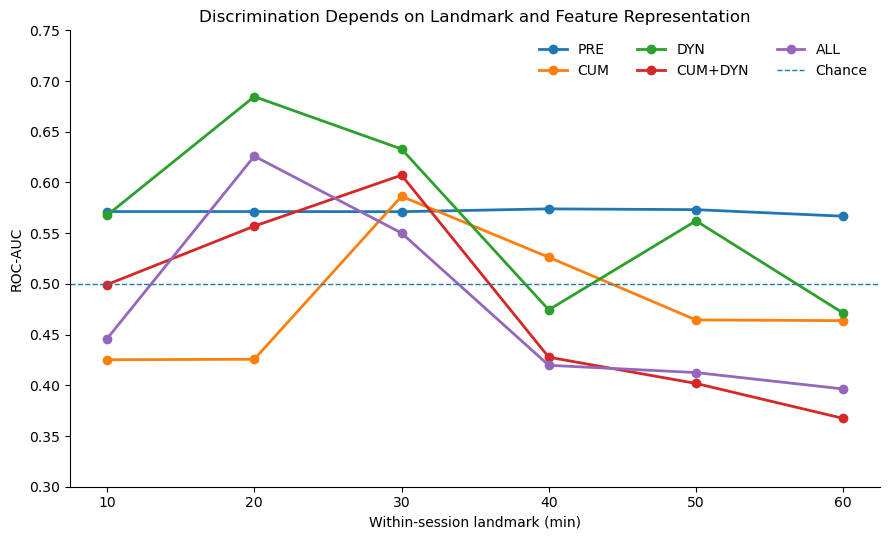

In [92]:
import matplotlib.pyplot as plt

# Keep only the most interpretable representations
plot_configs = ["PRE", "CUM", "DYN", "CUM+DYN", "ALL"]

plot_df = (
    ablation_results[
        ablation_results["configuration"].isin(plot_configs)
    ]
    .copy()
)

fig, ax = plt.subplots(figsize=(9, 5.5))

for config in plot_configs:
    tmp = (
        plot_df[plot_df["configuration"] == config]
        .sort_values("minute_x")
    )

    ax.plot(
        tmp["minute_x"],
        tmp["roc_auc"],
        marker="o",
        linewidth=2,
        label=config
    )

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="Chance"
)

ax.set_xlabel("Within-session landmark (min)")
ax.set_ylabel("ROC-AUC")
ax.set_title(
    "Discrimination Depends on Landmark and Feature Representation"
)

ax.set_xticks(LANDMARKS)
ax.set_ylim(0.30, 0.75)

ax.legend(
    frameon=False,
    ncol=3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "Figure2_Landmark_Representations.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figure2_Landmark_Representations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

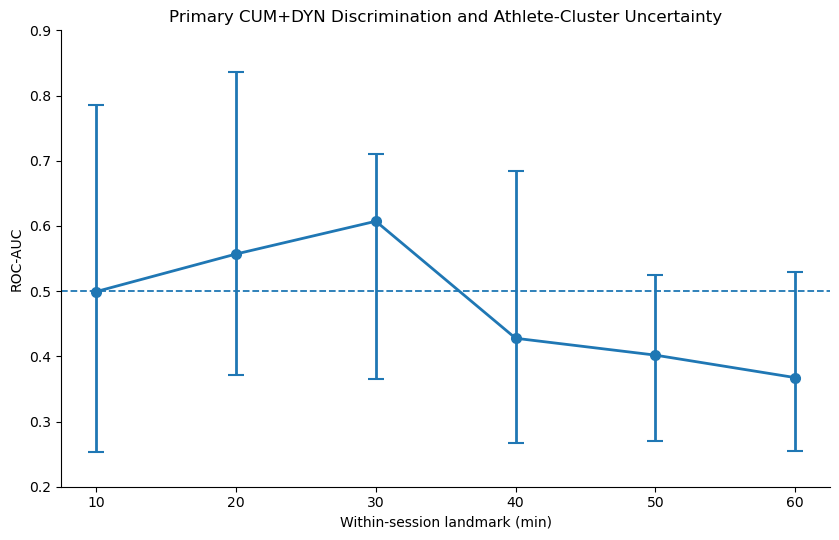

In [93]:
import matplotlib.pyplot as plt
import numpy as np

primary_uncertainty = (
    bootstrap_ablation[
        bootstrap_ablation["configuration"] == "CUM+DYN"
    ]
    .sort_values("minute_x")
    .copy()
)

x = primary_uncertainty["minute_x"].to_numpy()
y = primary_uncertainty["observed_roc_auc"].to_numpy()

lower_err = (
    y - primary_uncertainty["roc_ci_low"].to_numpy()
)

upper_err = (
    primary_uncertainty["roc_ci_high"].to_numpy() - y
)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.errorbar(
    x,
    y,
    yerr=[lower_err, upper_err],
    fmt="o-",
    linewidth=2,
    markersize=7,
    capsize=6,
    capthick=1.5
)

# Chance discrimination
ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.3
)

ax.set_xlabel("Within-session landmark (min)")
ax.set_ylabel("ROC-AUC")

ax.set_title(
    "Primary CUM+DYN Discrimination and Athlete-Cluster Uncertainty"
)

ax.set_xticks([10, 20, 30, 40, 50, 60])
ax.set_ylim(0.20, 0.90)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "Figure3_Primary_Uncertainty.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figure3_Primary_Uncertainty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()